In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Setup complete")

Setup complete


# DSM120 Financial Data Modelling

## Midterm Coursework

This notebook contains the complete analysis for the DSM120 Financial Data Modelling midterm coursework. The work is organised around a portfolio of time series datasets with different frequencies and characteristics, including high-frequency financial data, macroeconomic data, energy data, and environmental data.

The analysis will cover data exploration, stationarity, autocorrelation, autoregressive modelling, forecasting, Monte Carlo simulation, and an additional extension beyond the taught material.

# 1. Introduction

# 2. Dataset Portfolio

## 2.1 Overview

The portfolio consists of six datasets selected to represent different domains, frequencies and time series characteristics. Together they provide a diverse collection of trending and non-trending series, seasonal and non-seasonal behaviour, and varying levels of volatility. This diversity allows different modelling techniques to be evaluated across multiple types of time series throughout the coursework.

In [2]:
# Project directories

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"

FINANCIAL_DIR = DATA_DIR / "financial"
MACRO_DIR = DATA_DIR / "macro"
ENVIRONMENTAL_DIR = DATA_DIR / "environmental"
ENERGY_DIR = DATA_DIR / "energy"

print("Project root:", PROJECT_ROOT.resolve())

Project root: /Users/komal/Downloads/Financial Data Modeling


In [3]:
# Display available datasets

for folder in [FINANCIAL_DIR, MACRO_DIR, ENVIRONMENTAL_DIR, ENERGY_DIR]:
    print(f"\n{folder.name.upper()}")
    for file in sorted(folder.glob("*")):
        print("   ", file.name)


FINANCIAL
    .DS_Store
    High Frequency Financial Data-20260709
    USDC-USDT.csv

MACRO
    GDP_Var.csv
    UK_job_vacancies.csv

ENVIRONMENTAL
    .DS_Store
    CO2_monthly.csv
    sunspots.csv
    temperatures.csv

ENERGY
    german_daily.csv
    solar_generation.csv


## 2.2 Loading and inspecting the datasets

Before beginning the analysis, each dataset is loaded and inspected to verify its structure, identify missing values, determine the date range and confirm the variables available for modelling. This step ensures the data are suitable for subsequent time series analysis.

In [4]:
def inspect_dataset(df, name):
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)

    print(f"Shape: {df.shape}")

    print("\nColumns")
    print(df.columns.tolist())

    print("\nMissing values")
    print(df.isna().sum())

    print("\nFirst 5 rows")
    display(df.head())

    print("\nLast 5 rows")
    display(df.tail())

In [5]:
co2_df = pd.read_csv(
    ENVIRONMENTAL_DIR / "CO2_monthly.csv"
)

inspect_dataset(co2_df, "CO₂ Monthly")

Dataset: CO₂ Monthly
Shape: (727, 6)

Columns
['Date', 'Decimal Date', 'Average', 'Interpolated', 'Trend', 'Number of Days']

Missing values
Date              0
Decimal Date      0
Average           0
Interpolated      0
Trend             0
Number of Days    0
dtype: int64

First 5 rows


,Date,Decimal Date,Average,Interpolated,Trend,Number of Days
0,1958-03-01,"1,958.2080",315.7100,315.7100,314.6200,-1
1,1958-04-01,"1,958.2920",317.4500,317.4500,315.2900,-1
2,1958-05-01,"1,958.3750",317.5000,317.5000,314.7100,-1
3,1958-06-01,"1,958.4580",-99.9900,317.1000,314.8500,-1
4,1958-07-01,"1,958.5420",315.8600,315.8600,314.9800,-1



Last 5 rows


,Date,Decimal Date,Average,Interpolated,Trend,Number of Days
722,2018-05-01,"2,018.3750",411.2400,411.2400,407.9100,24
723,2018-06-01,"2,018.4580",410.7900,410.7900,408.4900,29
724,2018-07-01,"2,018.5420",408.7100,408.7100,408.3200,27
725,2018-08-01,"2,018.6250",406.9900,406.9900,408.9000,30
726,2018-09-01,"2,018.7080",405.5100,405.5100,409.0200,29


## Initial inspection identified that the dataset contained placeholder values (-99.99) representing missing observations. These were identified during exploratory analysis and handled appropriately before modelling.

In [6]:
# Summary statistics

co2_df.describe()

,Decimal Date,Average,Interpolated,Trend,Number of Days
count,727.0000,727.0000,727.0000,727.0000,727.0000
mean,"1,988.4583",349.5558,353.6407,353.6331,18.3411
std,17.5009,52.0686,27.4431,27.3690,12.2420
min,"1,958.2080",-99.9900,312.6600,314.6200,-1.0000
25%,"1,973.3335",328.4250,328.5550,329.2950,-1.0000
50%,"1,988.4580",351.3100,351.3100,351.3700,24.0000
75%,"2,003.5835",375.7000,375.7000,376.1350,28.0000
max,"2,018.7080",411.2400,411.2400,409.0200,31.0000


In [7]:
co2_df[co2_df["Average"] == -99.99]

,Date,Decimal Date,Average,Interpolated,Trend,Number of Days
3,1958-06-01,"1,958.4580",-99.9900,317.1000,314.8500,-1
7,1958-10-01,"1,958.7920",-99.9900,312.6600,315.6100,-1
71,1964-02-01,"1,964.1250",-99.9900,320.0700,319.6100,-1
72,1964-03-01,"1,964.2080",-99.9900,320.7300,319.5500,-1
73,1964-04-01,"1,964.2920",-99.9900,321.7700,319.4800,-1
213,1975-12-01,"1,975.9580",-99.9900,330.5900,331.6000,0
313,1984-04-01,"1,984.2920",-99.9900,346.8400,344.2700,2


In [8]:
print("Number of placeholder values:",
      (co2_df["Average"] == -99.99).sum())

Number of placeholder values: 7


# 3. Part 1

## 3.1 Topic 1: Building the Time Series Portfolio

### 3.1.1 Objective

The purpose of this section is to construct a portfolio of real-world time-based datasets and convert each dataset into a consistent time series format. Following the module convention, each time series is represented as a pandas DataFrame with a temporal index and one numeric data column.

The portfolio contains datasets from financial, economic, energy and environmental domains. The datasets were selected to provide different frequencies and behaviours, including trending and non-trending series, seasonal and non-seasonal patterns, and varying levels of stability and volatility.

In [9]:
# List all files available in the data directory

for folder in [FINANCIAL_DIR, MACRO_DIR, ENVIRONMENTAL_DIR, ENERGY_DIR]:
    print(f"\n{folder.name.upper()}")
    print("-" * 40)

    for file in sorted(folder.rglob("*")):
        if file.is_file():
            print(file.relative_to(DATA_DIR))


FINANCIAL
----------------------------------------
financial/.DS_Store
financial/High Frequency Financial Data-20260709/AUD 07042014 2011.csv
financial/High Frequency Financial Data-20260709/CAD 07042014 2011.csv
financial/High Frequency Financial Data-20260709/CHF 07042014 2011.csv
financial/High Frequency Financial Data-20260709/FTSE 04072014 2011.csv
financial/High Frequency Financial Data-20260709/GBP 07042014 2011.csv
financial/High Frequency Financial Data-20260709/Gold 07042014 2011.csv
financial/High Frequency Financial Data-20260709/JPY 07042014 2011.csv
financial/High Frequency Financial Data-20260709/NZD 07042014 2011.csv
financial/High Frequency Financial Data-20260709/SP 500 04072014 2011.csv
financial/High Frequency Financial Data-20260709/WTI 07042014 2011.csv
financial/High Frequency Financial Data-20260709/eur 07042014 2011.csv
financial/USDC-USDT.csv

MACRO
----------------------------------------
macro/GDP_Var.csv
macro/UK_job_vacancies.csv

ENVIRONMENTAL
----------

In [10]:
# Files selected for the initial portfolio

portfolio_files = {
    "S&P 500": FINANCIAL_DIR
    / "High Frequency Financial Data-20260709"
    / "SP 500 04072014 2011.csv",

    "Gold": FINANCIAL_DIR
    / "High Frequency Financial Data-20260709"
    / "Gold 07042014 2011.csv",

    "CO2": ENVIRONMENTAL_DIR / "CO2_monthly.csv",

    "Temperature": ENVIRONMENTAL_DIR / "temperatures.csv",

    "UK Job Vacancies": MACRO_DIR / "UK_job_vacancies.csv",

    "German Electricity": ENERGY_DIR / "german_daily.csv"
}

for name, filepath in portfolio_files.items():
    print("\n" + "=" * 70)
    print(name)
    print(filepath)
    print("=" * 70)

    sample = pd.read_csv(filepath, nrows=5)

    print("Columns:")
    print(sample.columns.tolist())

    display(sample)


S&P 500
../data/financial/High Frequency Financial Data-20260709/SP 500 04072014 2011.csv
Columns:
['Date', 'Time', 'Bar#', 'Bar Index', 'Tick Range', 'Open', 'High', 'Low', 'Close']


,Date,Time,Bar#,Bar Index,Tick Range,Open,High,Low,Close
0,04/04/2014,21:06:00,501724/501724,0,0,"1,865.0900","1,865.0900","1,865.0900","1,865.0900"
1,04/04/2014,21:04:00,501723/501724,-1,0,"1,865.1000","1,865.1000","1,865.1000","1,865.1000"
2,04/04/2014,21:03:00,501722/501724,-2,2,"1,865.1300","1,865.1300","1,865.1100","1,865.1100"
3,04/04/2014,21:02:00,501721/501724,-3,4,"1,865.1800","1,865.1800","1,865.1400","1,865.1400"
4,04/04/2014,21:01:00,501720/501724,-4,6,"1,865.2600","1,865.2600","1,865.2000","1,865.2000"



Gold
../data/financial/High Frequency Financial Data-20260709/Gold 07042014 2011.csv
Columns:
['Date', 'Time', 'Bar#', 'Bar Index', 'Tick Range', 'Open', 'High', 'Low', 'Close']


,Date,Time,Bar#,Bar Index,Tick Range,Open,High,Low,Close
0,07/04/2014,13:54:00,886801/886801,0,80,"1,298.6000","1,299.0000","1,298.2000","1,298.5000"
1,07/04/2014,13:53:00,886800/886801,-1,69,"1,299.0400","1,299.2900","1,298.6000","1,298.6000"
2,07/04/2014,13:52:00,886799/886801,-2,39,"1,299.0700","1,299.2900","1,298.9000","1,298.9000"
3,07/04/2014,13:51:00,886798/886801,-3,31,"1,299.0000","1,299.2100","1,298.9000","1,299.0900"
4,07/04/2014,13:50:00,886797/886801,-4,52,"1,298.8000","1,299.2200","1,298.7000","1,299.1700"



CO2
../data/environmental/CO2_monthly.csv
Columns:
['Date', 'Decimal Date', 'Average', 'Interpolated', 'Trend', 'Number of Days']


...

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.0340,3.5740,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.0830,3.7020,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.6260,3.0760,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.4900,2.4510,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.5730,2.0720,NaN,NaN,NaN,NaN,NaN,NaN



UK Job Vacancies
../data/macro/UK_job_vacancies.csv
Columns:
['Month', 'Vacancies']


,Month,Vacancies
0,2001 MAY,567.0000
1,2001 JUN,563.0000
2,2001 JUL,553.0000
3,2001 AUG,552.0000
4,2001 SEP,535.0000



German Electricity
../data/energy/german_daily.csv
Columns:
['Date', 'Consumption', 'Wind', 'Solar', 'Wind+Solar']


,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,"1,069.1840",NaN,NaN,NaN
1,2006-01-02,"1,380.5210",NaN,NaN,NaN
2,2006-01-03,"1,442.5330",NaN,NaN,NaN
3,2006-01-04,"1,457.2170",NaN,NaN,NaN
4,2006-01-05,"1,477.1310",NaN,NaN,NaN


In [11]:
def create_time_series(df, date_column, value_column, dataset_name):
    """
    Convert a dataframe into the standard time-series representation.
    """

    ts = df[[date_column, value_column]].copy()

    ts[date_column] = pd.to_datetime(ts[date_column])

    ts = ts.set_index(date_column)

    ts = ts.sort_index()

    ts.columns = [dataset_name]

    return ts

In [12]:
co2_ts = create_time_series(
    co2_df,
    date_column="Date",
    value_column="Interpolated",
    dataset_name="CO2"
)

co2_ts.head()

,CO2
Date,
1958-03-01,315.7100
1958-04-01,317.4500
1958-05-01,317.5000
1958-06-01,317.1000
1958-07-01,315.8600


In [13]:
co2_ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 727 entries, 1958-03-01 to 2018-09-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CO2     727 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [14]:
# Load the selected datasets

sp500_df = pd.read_csv(portfolio_files["S&P 500"])
gold_df = pd.read_csv(portfolio_files["Gold"])
temperature_df = pd.read_csv(portfolio_files["Temperature"])
vacancies_df = pd.read_csv(portfolio_files["UK Job Vacancies"])
electricity_df = pd.read_csv(portfolio_files["German Electricity"])

In [15]:
# S&P 500: combine Date and Time into one timestamp

sp500_df["Datetime"] = pd.to_datetime(
    sp500_df["Date"] + " " + sp500_df["Time"],
    dayfirst=True
)

sp500_ts = create_time_series(
    sp500_df,
    date_column="Datetime",
    value_column="Close",
    dataset_name="S&P 500"
)

In [16]:
# Gold: combine Date and Time into one timestamp

gold_df["Datetime"] = pd.to_datetime(
    gold_df["Date"] + " " + gold_df["Time"],
    dayfirst=True
)

gold_ts = create_time_series(
    gold_df,
    date_column="Datetime",
    value_column="Close",
    dataset_name="Gold"
)

In [17]:
# Global land temperature

temperature_ts = create_time_series(
    temperature_df,
    date_column="dt",
    value_column="LandAverageTemperature",
    dataset_name="Temperature"
)

In [18]:
# UK job vacancies

# Convert the Month column explicitly

vacancies_df["Month"] = pd.to_datetime(
    vacancies_df["Month"],
    format="%Y %b"
)

vacancies_ts = create_time_series(
    vacancies_df,
    date_column="Month",
    value_column="Vacancies",
    dataset_name="UK Job Vacancies"
)

In [19]:
# German electricity consumption

electricity_ts = create_time_series(
    electricity_df,
    date_column="Date",
    value_column="Consumption",
    dataset_name="Electricity Consumption"
)

In [20]:
portfolio = {
    "S&P 500": sp500_ts,
    "Gold": gold_ts,
    "CO2": co2_ts,
    "Temperature": temperature_ts,
    "UK Job Vacancies": vacancies_ts,
    "German Electricity": electricity_ts
}

In [21]:
for name, ts in portfolio.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("Shape:", ts.shape)
    print("Index type:", type(ts.index).__name__)
    print("Columns:", ts.columns.tolist())
    print("Start:", ts.index.min())
    print("End:", ts.index.max())
    print("Missing values:", ts.isna().sum().iloc[0])


S&P 500
Shape: (501724, 1)
Index type: DatetimeIndex
Columns: ['S&P 500']
Start: 2009-03-11 17:07:00
End: 2014-04-04 21:06:00
Missing values: 0

Gold
Shape: (886801, 1)
Index type: DatetimeIndex
Columns: ['Gold']
Start: 2011-10-26 15:50:00
End: 2014-04-07 13:54:00
Missing values: 0

CO2
Shape: (727, 1)
Index type: DatetimeIndex
Columns: ['CO2']
Start: 1958-03-01 00:00:00
End: 2018-09-01 00:00:00
Missing values: 0

Temperature
Shape: (3192, 1)
Index type: DatetimeIndex
Columns: ['Temperature']
Start: 1750-01-01 00:00:00
End: 2015-12-01 00:00:00
Missing values: 12

UK Job Vacancies
Shape: (244, 1)
Index type: DatetimeIndex
Columns: ['UK Job Vacancies']
Start: 2001-05-01 00:00:00
End: 2021-08-01 00:00:00
Missing values: 0

German Electricity
Shape: (4383, 1)
Index type: DatetimeIndex
Columns: ['Electricity Consumption']
Start: 2006-01-01 00:00:00
End: 2017-12-31 00:00:00
Missing values: 0


In [22]:
temperature_ts[temperature_ts.isna().any(axis=1)]

,Temperature
dt,
1750-11-01,NaN
1751-05-01,NaN
1751-07-01,NaN
1751-10-01,NaN
1751-11-01,NaN
1751-12-01,NaN
1752-02-01,NaN
1752-05-01,NaN
1752-06-01,NaN


### 3.1.5 Time Series Visualisation

To gain an initial understanding of the behaviour of each dataset, a line plot is produced for every time series. These visualisations provide an overview of long-term trends, variability and potential seasonal patterns, and will inform the modelling approaches used in later topics.

In [23]:
def plot_time_series(ts, title):
    plt.figure(figsize=(12, 4))

    plt.plot(ts.index, ts.iloc[:, 0], linewidth=1)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ts.columns[0])

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

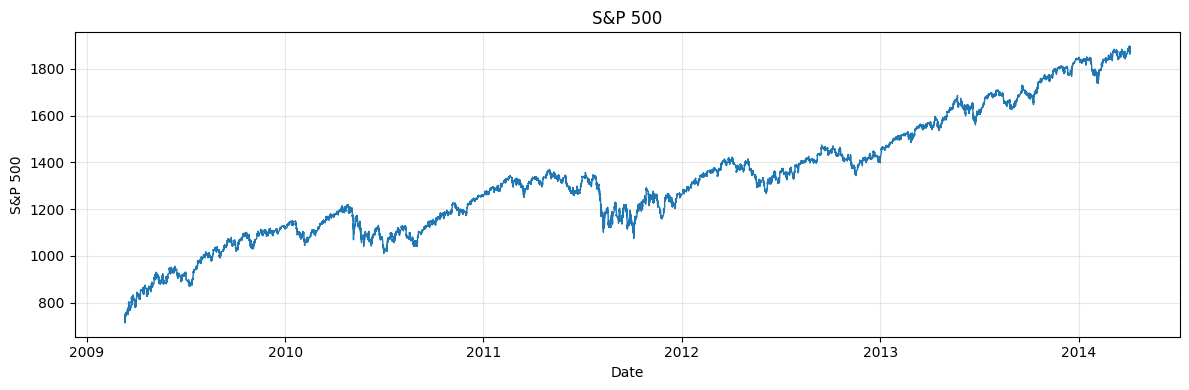

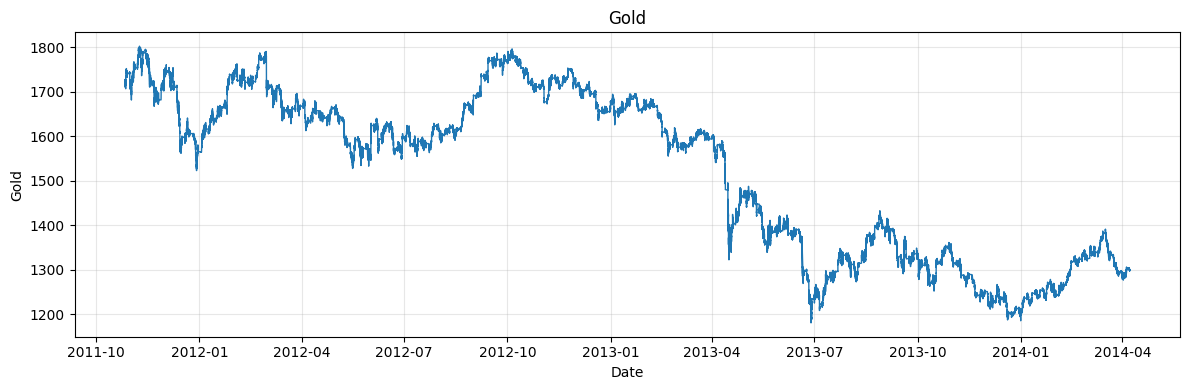

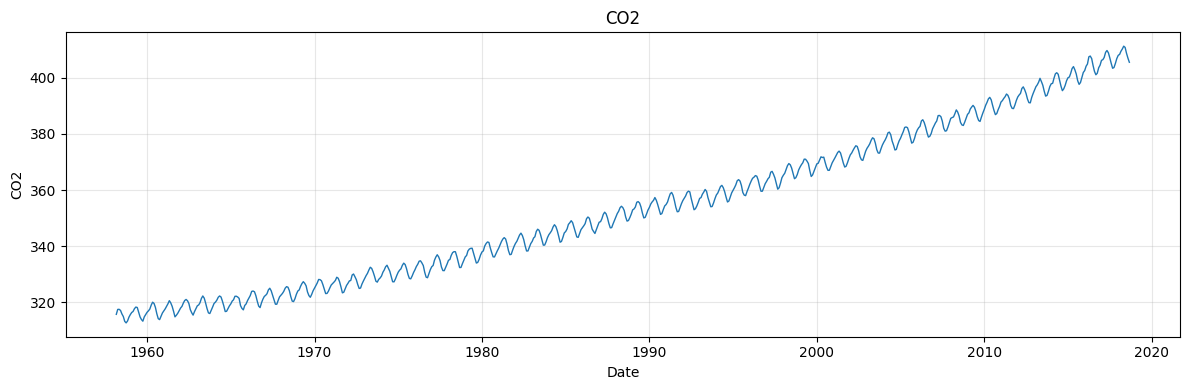

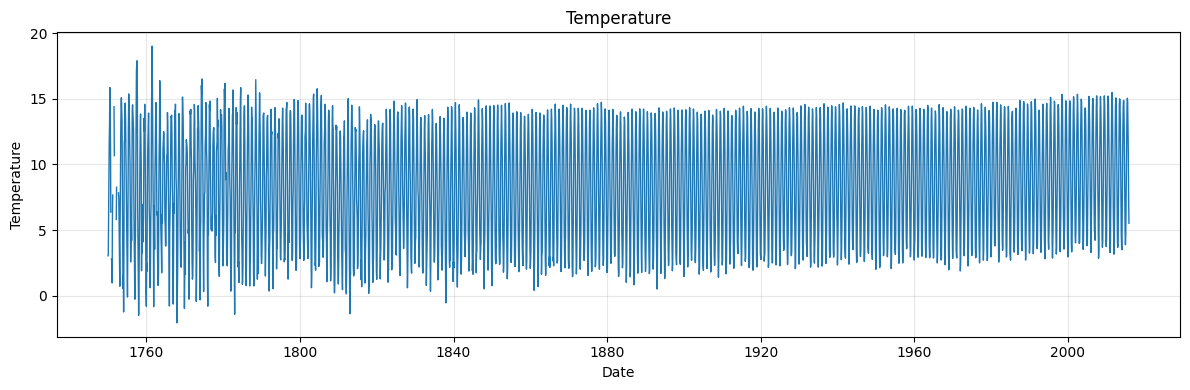

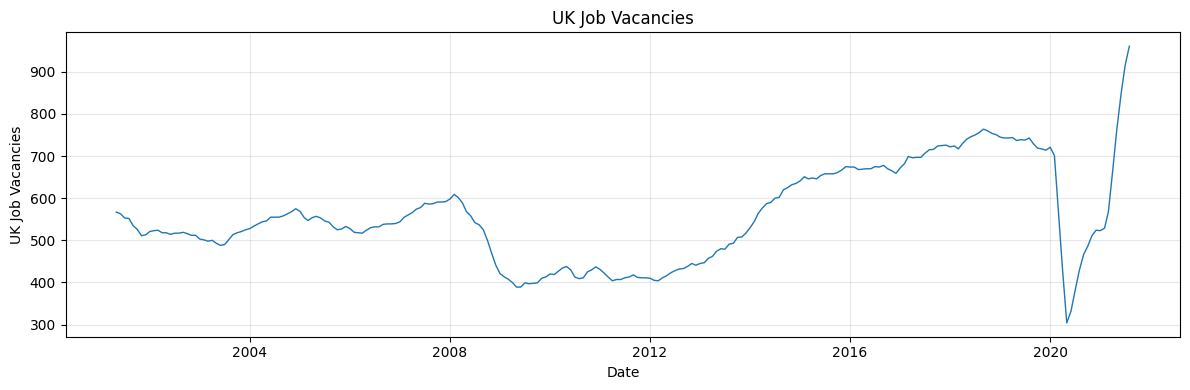

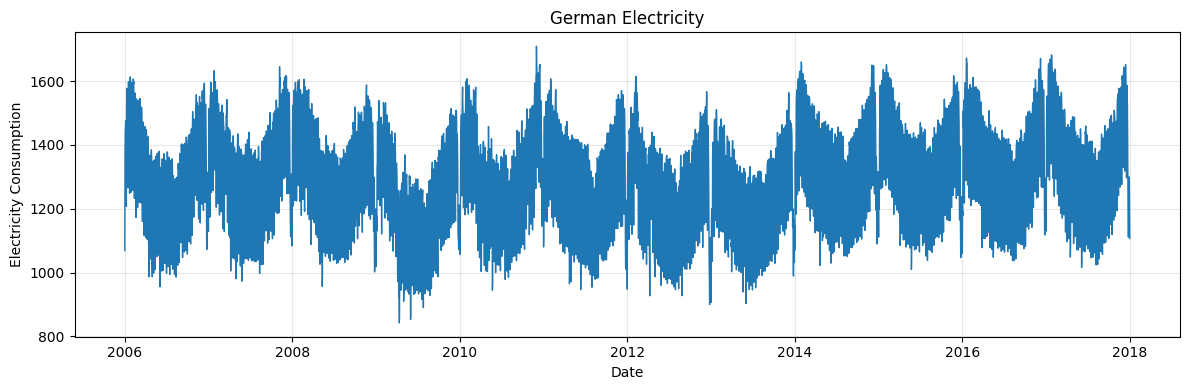

In [24]:
for name, ts in portfolio.items():
    plot_time_series(ts, name)

### 3.1.6 Discussion and Reflection

The six time series display clearly different temporal characteristics, supporting their selection as a diverse portfolio.

The S&P 500 and Gold datasets are minute-level financial series. Both contain substantially more observations than the other datasets and show frequent short-term movements in price. The S&P 500 represents an equity market index, while Gold represents a commodity, allowing financial behaviour to be compared across two different asset classes. Their high frequency and short-term variability make them suitable for the later analysis of alternative sampling frequencies, autoregressive models and forecast uncertainty.

The atmospheric CO₂ series shows a strong long-term upward trend together with repeated short-term fluctuations. The use of the `Interpolated` column avoids the seven invalid placeholder observations recorded as `-99.99` in the original `Average` column. This provides a complete monthly series while preserving the temporal sequence.

The global land temperature series contains pronounced annual variation and evidence of change over the longer period. Unlike the CO₂ series, it contains 12 missing observations. These values will need to be handled before methods requiring a complete series are applied. The dataset is nevertheless useful because it combines recurring seasonal behaviour with longer-term movement.

UK job vacancies display macroeconomic variation over time. The series is less regular than the environmental datasets and is likely to reflect changes in economic conditions, including periods of growth and contraction. It therefore provides a useful example of a monthly economic series affected by structural events rather than only regular seasonal variation.

German electricity consumption shows repeated variation over daily observations. The recurring movements are consistent with calendar-related patterns in electricity demand, while the longer time span may also contain broader seasonal changes. This makes the dataset useful for examining how periodic behaviour affects time series analysis.

Overall, the portfolio includes minute-level, daily and monthly observations and covers financial, economic, energy and environmental domains. It contains relatively volatile financial prices, strongly trending environmental series, cyclical economic behaviour and recurring energy-demand patterns. The datasets therefore provide a suitable basis for comparing how different time series methods perform under different conditions.

### 3.1.7 Critical Evaluation

The main strength of the portfolio is its diversity. Using datasets with different frequencies, lengths and behavioural characteristics should make it possible to evaluate whether a method performs consistently or is sensitive to features such as trend, seasonality and volatility.

However, direct comparisons must be made carefully. The datasets use different units, cover different periods and contain very different numbers of observations. The minute-level financial datasets are also likely to contain market closures and irregular gaps, while the temperature series includes missing observations. Consequently, later analyses may require dataset-specific preparation, including resampling, treatment of missing values, transformation or selection of shorter comparable periods.

At this stage, every dataset has been transformed into the module's standard representation of a pandas DataFrame with a temporal index and one numeric data column. Each series has also been visualised, satisfying the initial portfolio requirements. The portfolio may be refined later if particular methods require additional characteristics or alternative datasets.

### 3.1.4 Data Quality Assessment

Before undertaking any modelling, each dataset was examined for data quality issues, including missing values, placeholder values and inconsistencies in the time index.

The CO₂ dataset did not contain missing values according to the CSV file, but seven observations in the `Average` column were represented by the placeholder value `-99.99`, which does not represent a valid atmospheric CO₂ concentration. The corresponding `Interpolated` values were therefore selected as the modelling series.

The temperature dataset contained twelve genuine missing observations. These were identified during the initial inspection and will be addressed before statistical modelling is performed. The remaining datasets contained no missing observations after conversion to the standard time-series representation.

In [25]:
# Missing observations in the temperature series

temperature_ts[temperature_ts["Temperature"].isna()]

,Temperature
dt,
1750-11-01,NaN
1751-05-01,NaN
1751-07-01,NaN
1751-10-01,NaN
1751-11-01,NaN
1751-12-01,NaN
1752-02-01,NaN
1752-05-01,NaN
1752-06-01,NaN


In [26]:
temperature_ts.isna().sum()

Temperature    12
dtype: int64

The temperature dataset contained twelve missing observations, all occurring during the early years of the record (1750–1752). Given the small number of isolated gaps relative to the total dataset size, linear interpolation was used to estimate the missing values. After preprocessing, all datasets were complete and suitable for subsequent time series analysis. These represent a very small proportion of the overall dataset and are isolated rather than forming long gaps. Since many of the methods used later in the coursework require complete time series, linear interpolation is used to estimate the missing values while preserving the continuity of the series.

In [27]:
temperature_ts.describe()

,Temperature
count,"3,180.0000"
mean,8.3747
std,4.3813
min,-2.0800
25%,4.3120
50%,8.6105
75%,12.5482
max,19.0210


In [28]:
summary = pd.DataFrame({
    "Observations": [len(ts) for ts in portfolio.values()],
    "Start": [ts.index.min().date() for ts in portfolio.values()],
    "End": [ts.index.max().date() for ts in portfolio.values()],
    "Missing Values": [ts.isna().sum().iloc[0] for ts in portfolio.values()]
}, index=portfolio.keys())

summary

,Observations,Start,End,Missing Values
S&P 500,501724,2009-03-11,2014-04-04,0
Gold,886801,2011-10-26,2014-04-07,0
CO2,727,1958-03-01,2018-09-01,0
Temperature,3192,1750-01-01,2015-12-01,12
UK Job Vacancies,244,2001-05-01,2021-08-01,0
German Electricity,4383,2006-01-01,2017-12-31,0


In [29]:
temperature_ts = temperature_ts.interpolate(method="linear")

In [30]:
temperature_ts.isna().sum()

Temperature    0
dtype: int64

In [31]:
temperature_ts[temperature_ts.isna().any(axis=1)]

,Temperature
dt,


In [32]:
portfolio["Temperature"] = temperature_ts

In [33]:
summary = pd.DataFrame({
    "Observations": [len(ts) for ts in portfolio.values()],
    "Start": [ts.index.min().date() for ts in portfolio.values()],
    "End": [ts.index.max().date() for ts in portfolio.values()],
    "Missing Values": [ts.isna().sum().iloc[0] for ts in portfolio.values()]
}, index=portfolio.keys())

summary

,Observations,Start,End,Missing Values
S&P 500,501724,2009-03-11,2014-04-04,0
Gold,886801,2011-10-26,2014-04-07,0
CO2,727,1958-03-01,2018-09-01,0
Temperature,3192,1750-01-01,2015-12-01,0
UK Job Vacancies,244,2001-05-01,2021-08-01,0
German Electricity,4383,2006-01-01,2017-12-31,0


## 3.2 Topic 2: Stationarity, Trend and Seasonality

### Objective

This section examines stationarity, trend and seasonality across the time series portfolio. Financial returns are considered as potential stationary series, while transformations are applied to trending datasets to assess whether their behaviour can be stabilised.

First differences, second differences and relative differences are calculated for two trending datasets. Logarithmic transformations are also explored for series where changes may be multiplicative rather than additive. Finally, seasonal behaviour is examined and a seasonal adjustment is applied to a monthly time series.

### 3.2.1 Identifying Potentially Stationary Series

A stationary time series has statistical properties, such as its mean and variance, that remain broadly stable over time. Financial price levels commonly show trends and changing variability, making them unlikely to be stationary. Returns, however, represent changes between consecutive prices and are more likely to fluctuate around a relatively stable mean.

Log returns are calculated for the S&P 500 and Gold series and compared with their original price levels.

In [34]:
# Calculate log prices and log returns

sp500_log = np.log(sp500_ts["S&P 500"])
gold_log = np.log(gold_ts["Gold"])

sp500_returns = sp500_log.diff().dropna().to_frame("S&P 500 Log Return")
gold_returns = gold_log.diff().dropna().to_frame("Gold Log Return")

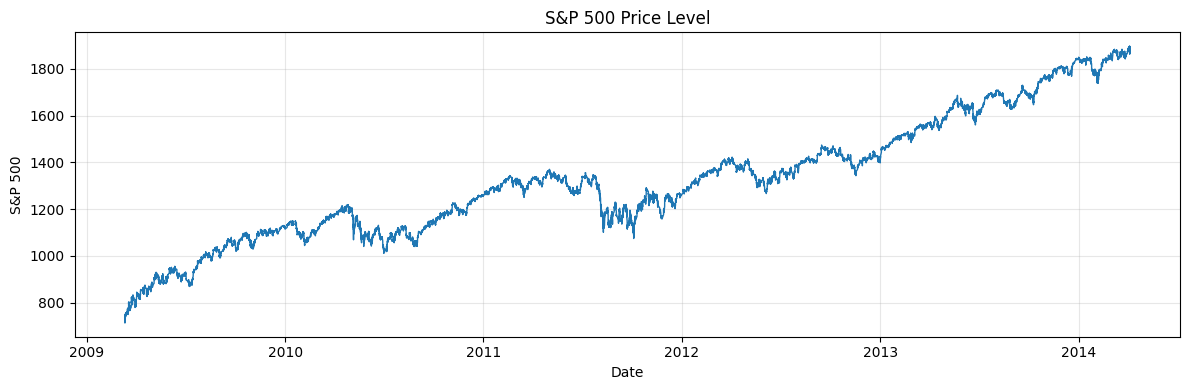

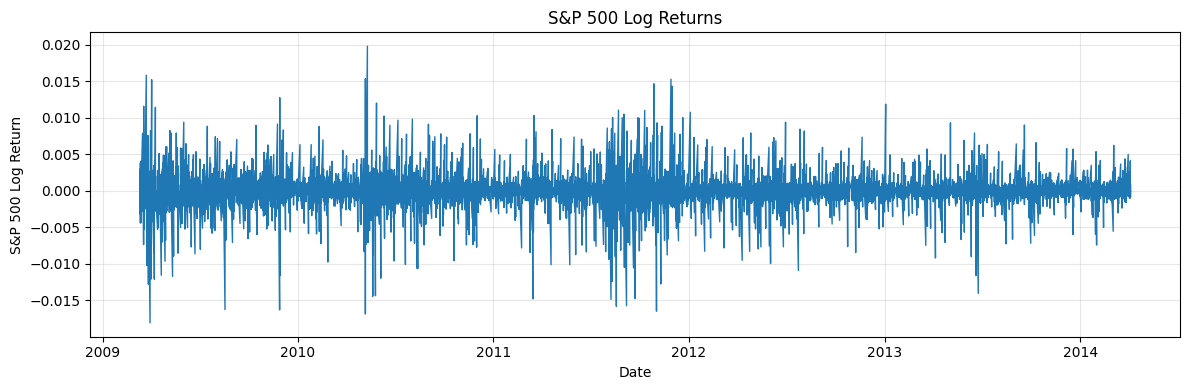

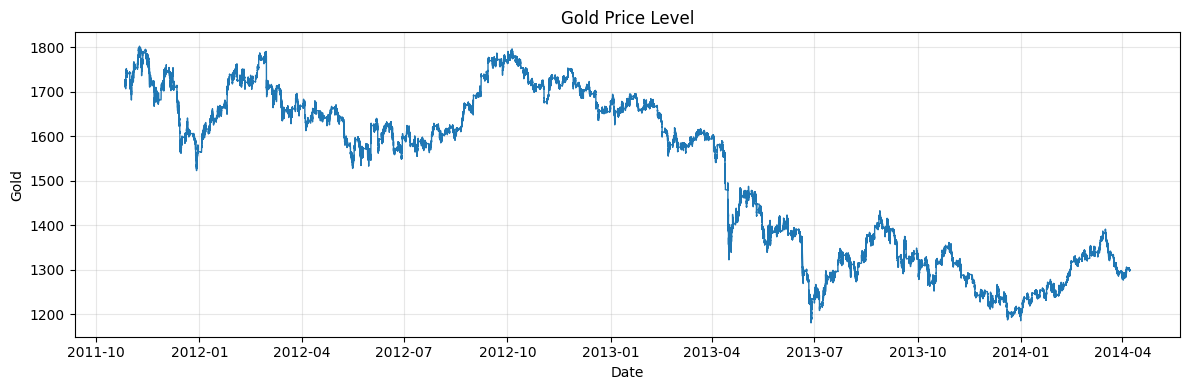

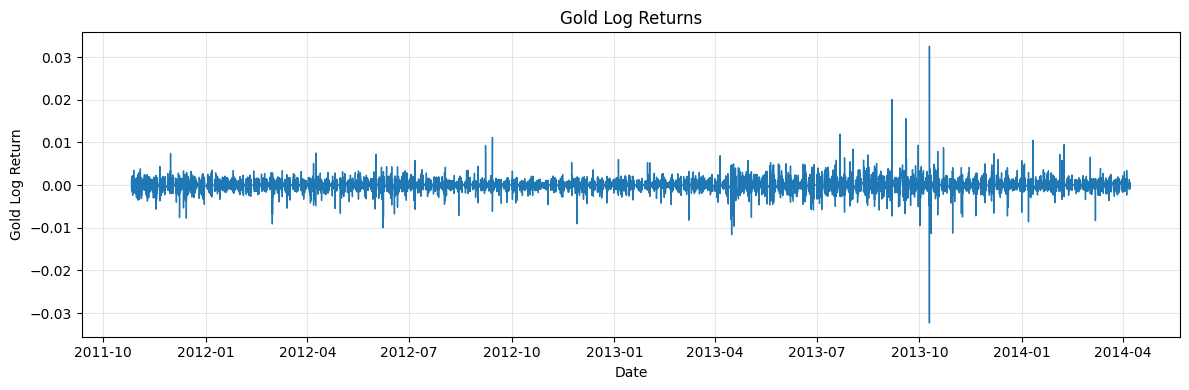

In [35]:
plot_time_series(sp500_ts, "S&P 500 Price Level")
plot_time_series(sp500_returns, "S&P 500 Log Returns")

plot_time_series(gold_ts, "Gold Price Level")
plot_time_series(gold_returns, "Gold Log Returns")

### Results and Discussion

The original S&P 500 and Gold price series both display changing levels over time and therefore do not satisfy the visual characteristics of stationary processes. Their means are not constant and both exhibit sustained trends.

After applying the logarithmic transformation and calculating first differences (log returns), both financial series fluctuate around approximately zero with no obvious long-term trend. Although periods of increased volatility remain, particularly during market stress, the transformed series are considerably closer to stationarity than the original prices.

These transformed return series are therefore more appropriate for many statistical time series models, which commonly assume that the underlying process is stationary.

### 3.2.2 Trend Removal Using Differencing

Differencing is one of the most common approaches for removing trend from a time series. First differences measure changes between consecutive observations, second differences measure changes in the first differences, and relative differences express proportional changes over time.

The transformations are demonstrated using the CO₂ concentration series and the UK job vacancies series.

In [36]:
for name, ts in portfolio.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("Shape:", ts.shape)
    print("Index type:", type(ts.index).__name__)
    print("Columns:", ts.columns.tolist())
    print("Start:", ts.index.min())
    print("End:", ts.index.max())
    print("Missing values:", ts.isna().sum().iloc[0])


S&P 500
Shape: (501724, 1)
Index type: DatetimeIndex
Columns: ['S&P 500']
Start: 2009-03-11 17:07:00
End: 2014-04-04 21:06:00
Missing values: 0

Gold
Shape: (886801, 1)
Index type: DatetimeIndex
Columns: ['Gold']
Start: 2011-10-26 15:50:00
End: 2014-04-07 13:54:00
Missing values: 0

CO2
Shape: (727, 1)
Index type: DatetimeIndex
Columns: ['CO2']
Start: 1958-03-01 00:00:00
End: 2018-09-01 00:00:00
Missing values: 0

Temperature
Shape: (3192, 1)
Index type: DatetimeIndex
Columns: ['Temperature']
Start: 1750-01-01 00:00:00
End: 2015-12-01 00:00:00
Missing values: 0

UK Job Vacancies
Shape: (244, 1)
Index type: DatetimeIndex
Columns: ['UK Job Vacancies']
Start: 2001-05-01 00:00:00
End: 2021-08-01 00:00:00
Missing values: 0

German Electricity
Shape: (4383, 1)
Index type: DatetimeIndex
Columns: ['Electricity Consumption']
Start: 2006-01-01 00:00:00
End: 2017-12-31 00:00:00
Missing values: 0


In [37]:
# CO2 transformations

co2_diff1 = co2_ts.diff()
co2_diff1.columns = ["CO₂ First Difference"]

co2_diff2 = co2_diff1.diff()
co2_diff2.columns = ["CO₂ Second Difference"]

co2_relative = co2_ts.pct_change()
co2_relative.columns = ["CO₂ Relative Difference"]


# UK vacancies transformations

vac_diff1 = vacancies_ts.diff()
vac_diff1.columns = ["Vacancies First Difference"]

vac_diff2 = vac_diff1.diff()
vac_diff2.columns = ["Vacancies Second Difference"]

vac_relative = vacancies_ts.pct_change()
vac_relative.columns = ["Vacancies Relative Difference"]

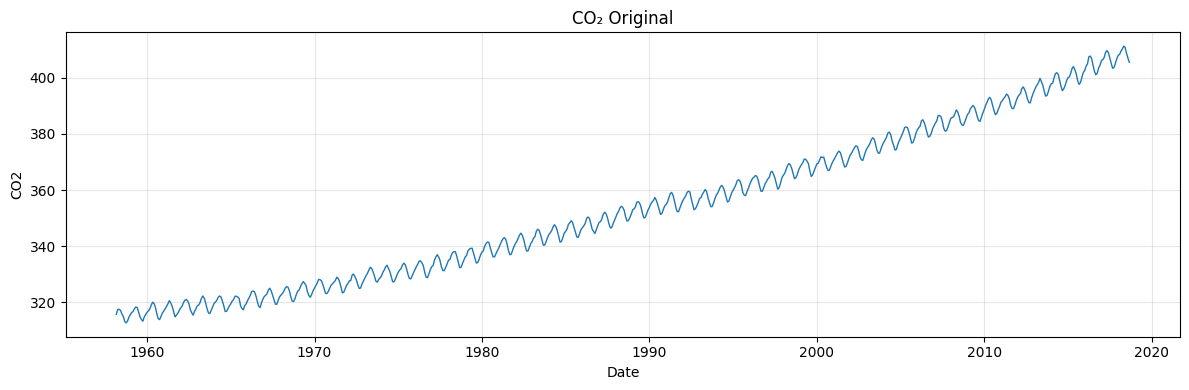

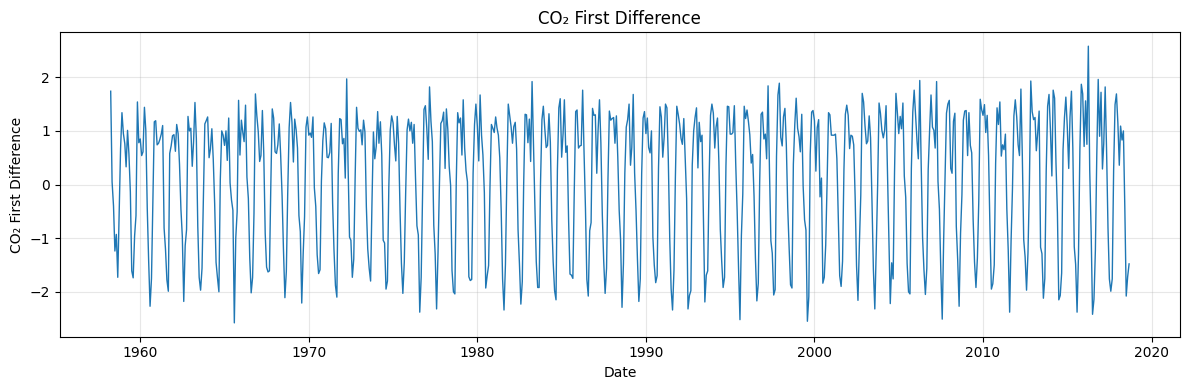

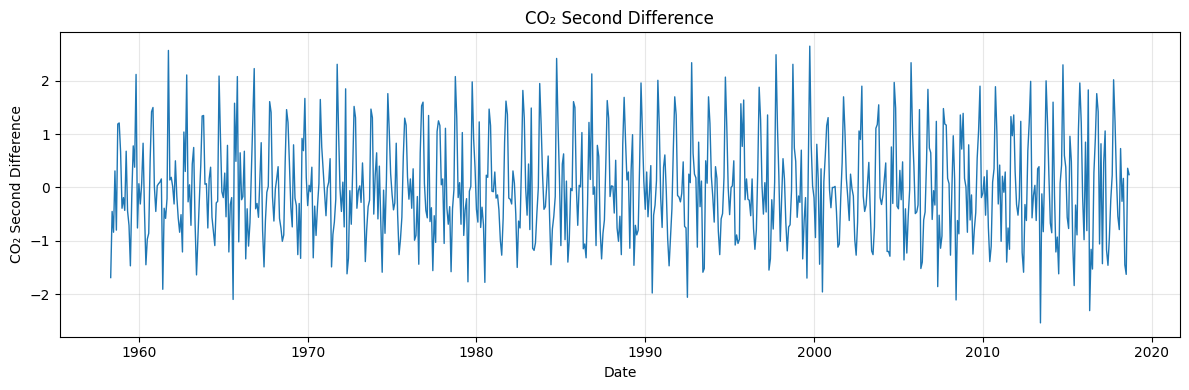

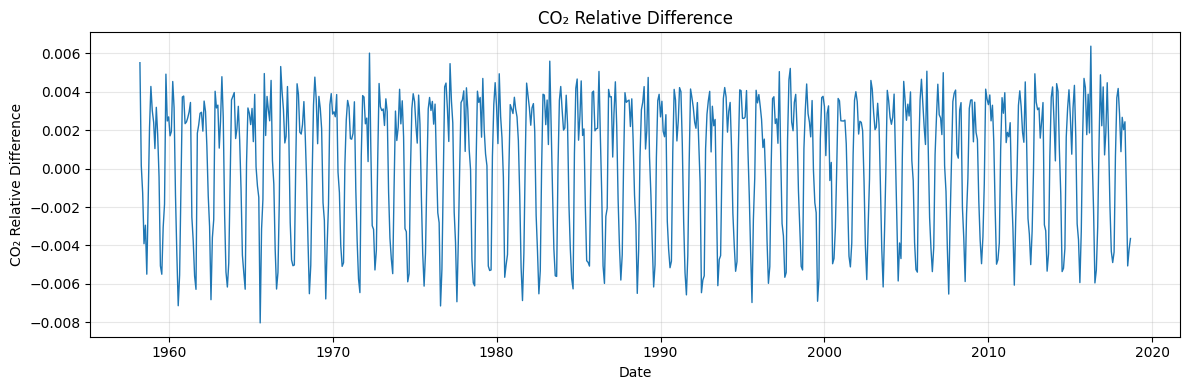

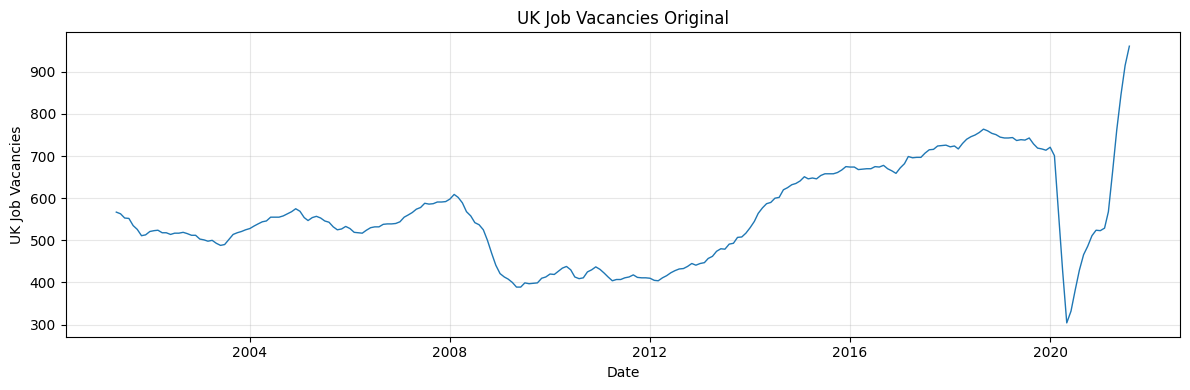

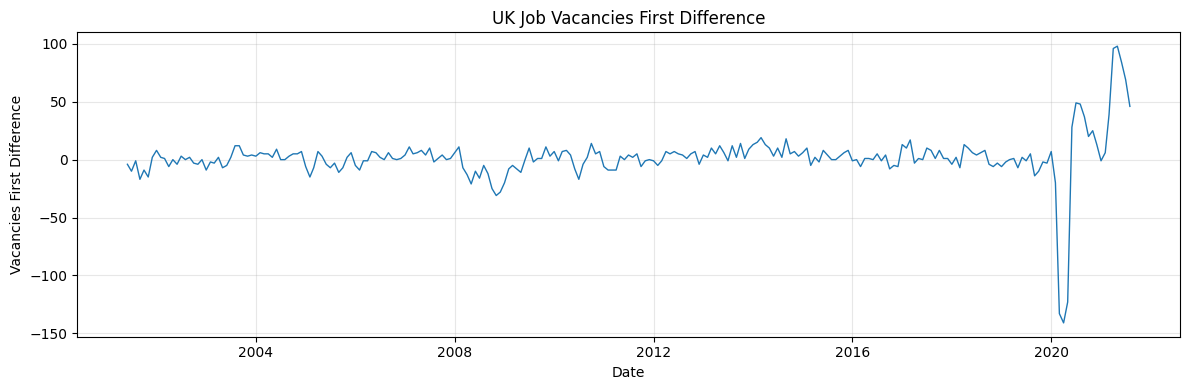

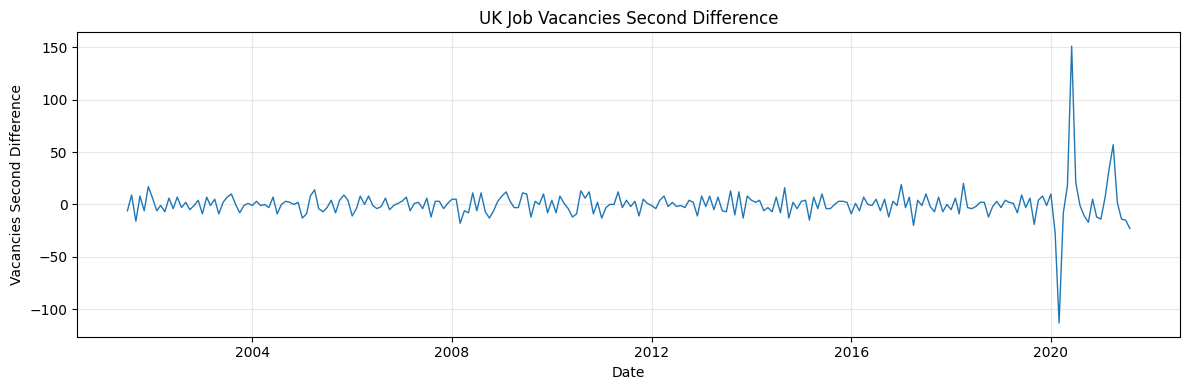

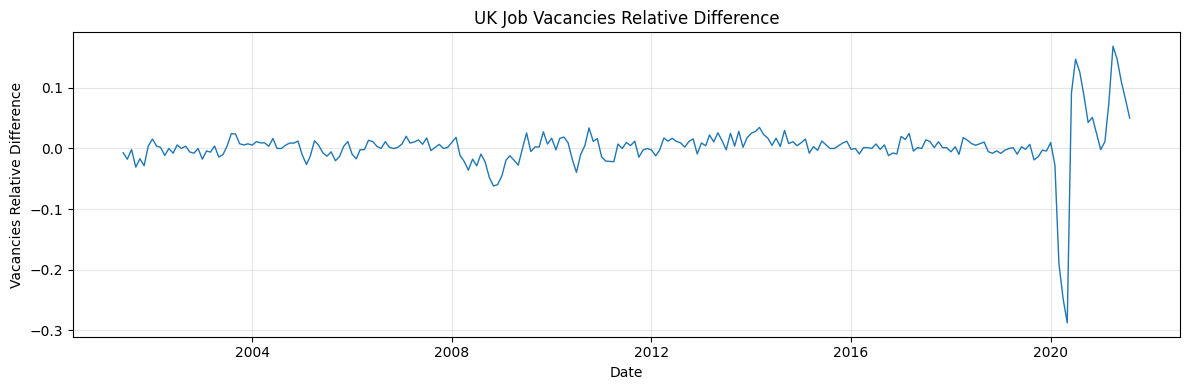

In [38]:
plot_time_series(co2_ts, "CO₂ Original")
plot_time_series(co2_diff1.dropna(), "CO₂ First Difference")
plot_time_series(co2_diff2.dropna(), "CO₂ Second Difference")
plot_time_series(co2_relative.dropna(), "CO₂ Relative Difference")

plot_time_series(vacancies_ts, "UK Job Vacancies Original")
plot_time_series(vac_diff1.dropna(), "UK Job Vacancies First Difference")
plot_time_series(vac_diff2.dropna(), "UK Job Vacancies Second Difference")
plot_time_series(vac_relative.dropna(), "UK Job Vacancies Relative Difference")

### Results and Discussion

The CO₂ concentration series displays both a strong upward trend and a clear annual seasonal cycle. The first difference removes much of the long-term trend but the seasonal oscillations remain visible, indicating that differencing alone does not eliminate seasonality. The second difference further reduces the persistence of the trend, producing a series that fluctuates more evenly around zero. The relative difference expresses monthly percentage changes, making the magnitude of change comparable across the full time period.

The UK job vacancies series exhibits long-term changes associated with economic conditions. The original series includes a pronounced decline during the 2008 financial crisis and an even larger disruption during the COVID-19 pandemic. Applying the first difference removes much of the long-term trend and centres the series around zero. The second difference highlights changes in the rate of movement, while the relative difference clearly captures the unusually large proportional changes during the pandemic period.

Overall, differencing substantially reduces trend in both datasets, although the CO₂ series retains clear seasonal behaviour. This demonstrates that trend and seasonality are distinct characteristics and often require different transformations before statistical modelling.

In [39]:
from statsmodels.tsa.seasonal import seasonal_decompose

### 3.2.3 Seasonal Adjustment

Seasonal behaviour refers to regular patterns that repeat at fixed intervals. The monthly CO₂ series exhibits a clear annual cycle, making it an appropriate candidate for seasonal decomposition.

An additive decomposition with a period of 12 months is used to separate the observed series into trend, seasonal and residual components.

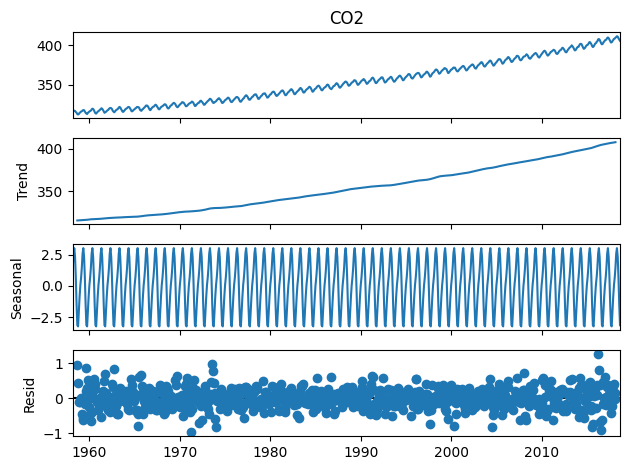

In [40]:
co2_decomposition = seasonal_decompose(
    co2_ts["CO2"],
    model="additive",
    period=12
)

co2_decomposition.plot()

plt.tight_layout()
plt.show()

In [41]:
co2_adjusted = (
    co2_ts["CO2"] -
    co2_decomposition.seasonal
).to_frame("Seasonally Adjusted CO₂")

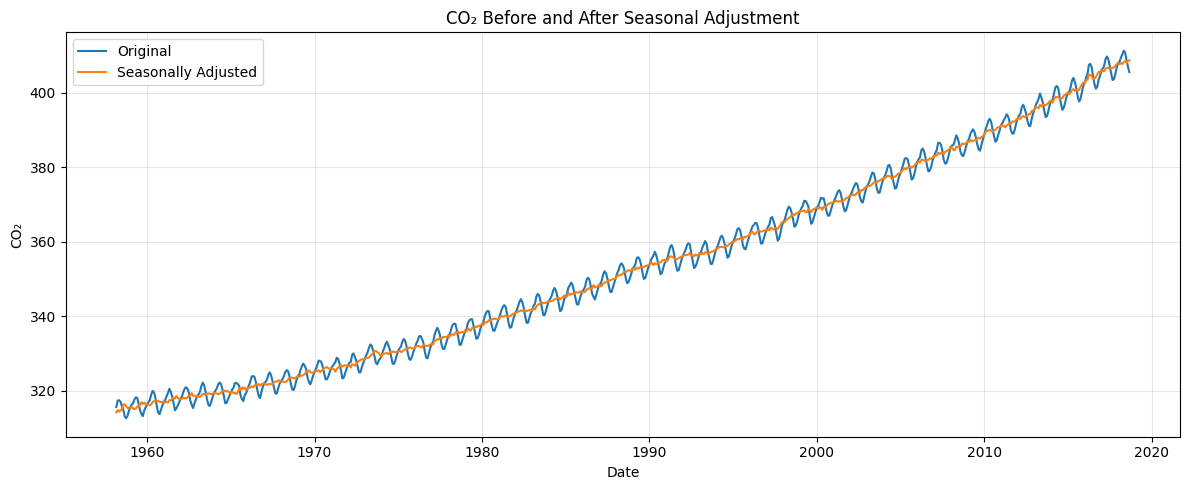

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(co2_ts.index,
         co2_ts["CO2"],
         label="Original")

plt.plot(co2_adjusted.index,
         co2_adjusted["Seasonally Adjusted CO₂"],
         label="Seasonally Adjusted")

plt.title("CO₂ Before and After Seasonal Adjustment")
plt.xlabel("Date")
plt.ylabel("CO₂")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Results and Discussion

The seasonal decomposition confirms that the CO₂ series contains three distinct components. The trend component shows a persistent long-term increase in atmospheric carbon dioxide concentrations, while the seasonal component captures the regular annual cycle observed throughout the dataset. The residual component contains the remaining short-term variation after removing both the trend and seasonal effects.

The seasonally adjusted series retains the long-term upward movement while removing the regular annual oscillations. This produces a smoother series that is more appropriate for analysing underlying long-run behaviour and for applying statistical models that assume the absence of strong seasonal effects.

The decomposition demonstrates that differencing alone is not always sufficient to prepare a time series for modelling. In the case of the CO₂ series, both trend and seasonality are present and require separate transformations. This illustrates the importance of understanding the characteristics of a dataset before selecting an appropriate modelling approach.

### Critical Evaluation

This topic demonstrated that different datasets require different preprocessing techniques before statistical modelling can be applied. Financial price series benefited from logarithmic transformation and differencing to produce return series that more closely resemble stationary processes. In contrast, environmental and macroeconomic datasets required additional treatment because they contained strong deterministic trends and, in the case of the CO₂ series, clear seasonal behaviour.

No single transformation was appropriate for every dataset. While first differencing substantially reduced trend, seasonal effects remained visible in the CO₂ series and therefore required seasonal decomposition. Likewise, the UK job vacancies series contained structural breaks associated with major economic events, illustrating that differencing cannot remove every form of non-stationarity.

These results emphasise that preprocessing decisions should be guided by the characteristics of each dataset rather than applying identical transformations to all time series. The transformed datasets provide a stronger foundation for the forecasting and autoregressive modelling techniques introduced in later topics.

### Topic 3

In [43]:
# Forecasting Functions 

import numpy as np
import pandas as pd

# Naive Forecast
def naive_forecast(train, test):
    forecast = np.repeat(train.iloc[-1], len(test))
    return pd.Series(forecast, index=test.index)

# Average Forecast
def average_forecast(train, test):
    forecast = np.repeat(train.mean(), len(test))
    return pd.Series(forecast, index=test.index)

# Seasonal Naive Forecast
def seasonal_naive_forecast(train, test, season_length):
    forecast = []

    for i in range(len(test)):
        forecast.append(train.iloc[-season_length + (i % season_length)])

    return pd.Series(forecast, index=test.index)

In [44]:
# Forecast evaluation 

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

def forecast_errors(actual, forecast):

    mae = mean_absolute_error(actual, forecast)

    rmse = np.sqrt(mean_squared_error(actual, forecast))

    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return mae, rmse, mape

In [45]:
# Train/ Test Helper 

def train_test_split(ts, train_size=0.8):

    split = int(len(ts) * train_size)

    train = ts.iloc[:split]

    test = ts.iloc[split:]

    return train, test

In [46]:
# Run all forecasts 

results = []

seasonal_data = {
    "CO2": 12,
    "UK Job Vacancies": 12,
    "Temperature": 12,
    "German Electricity": 365
}

for name, ts in portfolio.items():

    train, test = train_test_split(ts)

    actual = test.iloc[:, 0]

    # Naive
    naive = naive_forecast(train.iloc[:, 0], actual)
    mae, rmse, mape = forecast_errors(actual, naive)

    results.append([
        name,
        "Naive",
        mae,
        rmse,
        mape
    ])

    # Average
    avg = average_forecast(train.iloc[:, 0], actual)
    mae, rmse, mape = forecast_errors(actual, avg)

    results.append([
        name,
        "Average",
        mae,
        rmse,
        mape
    ])

    # Seasonal Naive
    if name in seasonal_data:

        season = seasonal_data[name]

        seasonal = seasonal_naive_forecast(
            train.iloc[:, 0],
            actual,
            season
        )

        mae, rmse, mape = forecast_errors(actual, seasonal)

        results.append([
            name,
            "Seasonal Naive",
            mae,
            rmse,
            mape
        ])

In [47]:
# Results table 

results_df = pd.DataFrame(
    results,
    columns=[
        "Dataset",
        "Method",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results_df

,Dataset,Method,MAE,RMSE,MAPE
0,S&P 500,Naive,165.1158,189.8037,9.3080
1,S&P 500,Average,504.6053,513.3567,29.0556
2,Gold,Naive,51.7028,63.0130,4.1290
3,Gold,Average,304.7826,308.1929,23.9286
4,CO2,Naive,12.5972,14.9576,3.1489
5,CO2,Average,51.5625,52.2394,13.0197
6,CO2,Seasonal Naive,13.7871,15.9401,3.4528
7,Temperature,Naive,4.1571,5.1053,86.0224
8,Temperature,Average,3.8065,4.2372,56.7280
9,Temperature,Seasonal Naive,0.5042,0.6290,7.2617


In [48]:
# Better comparision table
comparison = results_df.pivot(
    index="Dataset",
    columns="Method",
    values="RMSE"
)
comparison

Method,Average,Naive,Seasonal Naive
Dataset,,,
CO2,52.2394,14.9576,15.9401
German Electricity,169.9598,162.1845,192.0706
Gold,308.1929,63.0130,NaN
S&P 500,513.3567,189.8037,NaN
Temperature,4.2372,5.1053,0.6290
UK Job Vacancies,199.9852,143.5624,141.4602


## Discussion

Three simple forecasting methods were evaluated across the portfolio: naïve, average and seasonal naïve forecasting. Forecast accuracy was assessed using MAE, RMSE and MAPE.

The naïve forecast consistently outperformed the average forecast for the financial datasets (S&P 500 and Gold). This is expected because financial prices evolve gradually over time, making the most recent observation a better predictor than the historical average.

For the CO₂ series, both naïve and seasonal naïve forecasting produced similar forecasting errors. Although the data exhibit a clear annual seasonal pattern, the strong long-term upward trend reduces the advantage of relying solely on observations from the previous year.

Temperature data showed the largest improvement from seasonal naïve forecasting. The very low RMSE compared with the other methods reflects the strong and stable annual seasonal cycle in global temperatures.

UK job vacancies also benefited slightly from seasonal naïve forecasting. However, forecasting accuracy deteriorated during the COVID-19 period because of the sudden and unprecedented changes in the labour market.

For German electricity consumption, the naïve forecast achieved the lowest RMSE. Although electricity demand exhibits seasonal behaviour, short-term persistence appears to provide a stronger basis for forecasting over the chosen evaluation period.

Overall, the results demonstrate that no single forecasting method performs best for every dataset. Forecast accuracy depends on the underlying characteristics of the time series, including the presence of trends, seasonality and unexpected structural changes.

### Topic 4

In [49]:
# Imports 

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.ar_model import AutoReg

import matplotlib.pyplot as plt

In [50]:
# Create stationary series 

sp_stationary = np.log(sp500_ts).diff().dropna()

gold_stationary = np.log(gold_ts).diff().dropna()

co2_stationary = co2_ts.diff().dropna()

vac_stationary = vacancies_ts.diff().dropna()

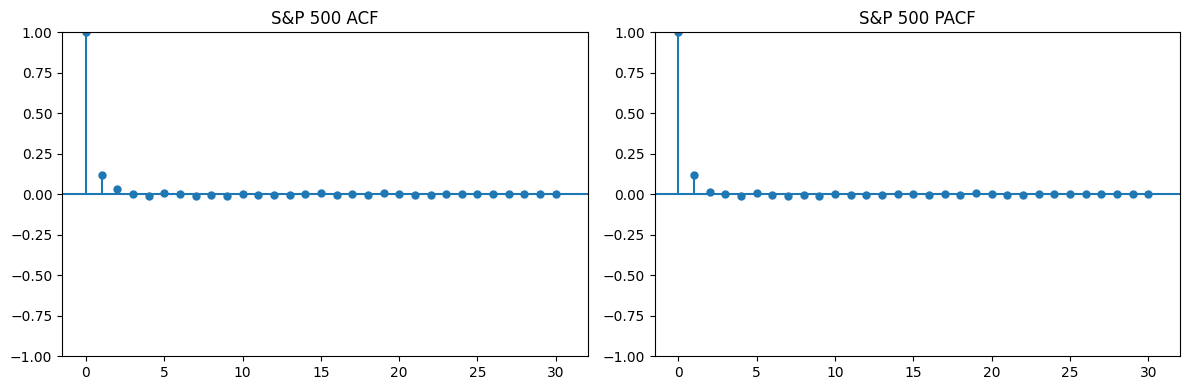

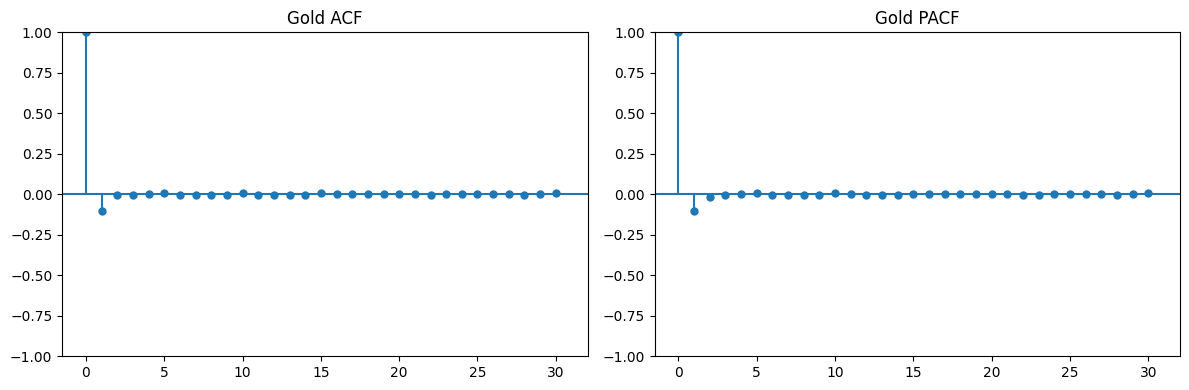

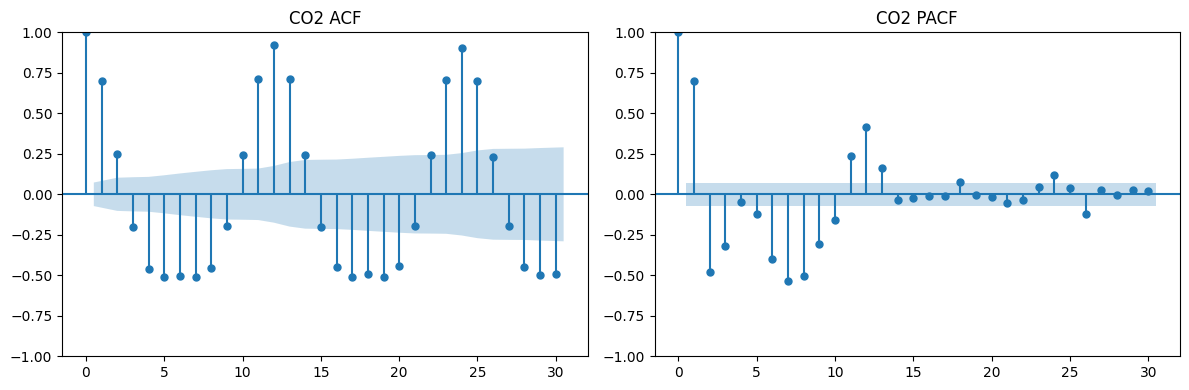

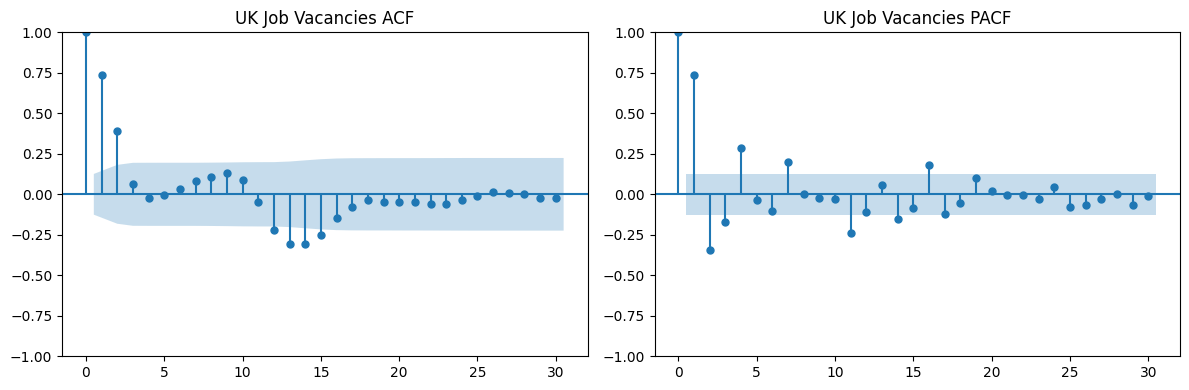

In [51]:
# PACF plots 

series_dict = {
    "S&P 500": sp_stationary,
    "Gold": gold_stationary,
    "CO2": co2_stationary,
    "UK Job Vacancies": vac_stationary
}

for name, ts in series_dict.items():

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    plot_acf(ts, lags=30, ax=ax[0])

    plot_pacf(ts, lags=30, ax=ax[1])

    ax[0].set_title(f"{name} ACF")

    ax[1].set_title(f"{name} PACF")

    plt.tight_layout()

    plt.show()

In [52]:
# Fit the AR Models 

from statsmodels.tsa.ar_model import AutoReg

ar_orders = {
    "S&P 500": 1,
    "Gold": 1,
    "CO2": 12,
    "UK Job Vacancies": 2
}

stationary_series = {
    "S&P 500": sp_stationary,
    "Gold": gold_stationary,
    "CO2": co2_stationary,
    "UK Job Vacancies": vac_stationary
}

for name, series in stationary_series.items():

    p = ar_orders[name]

    model = AutoReg(series, lags=p)

    fitted = model.fit()

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(fitted.summary())


S&P 500
                            AutoReg Model Results                             
Dep. Variable:                S&P 500   No. Observations:               501723
Model:                     AutoReg(1)   Log Likelihood             3135445.941
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Sat, 11 Jul 2026   AIC                       -6270885.882
Time:                        19:33:47   BIC                       -6270852.504
Sample:                             1   HQIC                      -6270876.434
                               501723                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.676e-06    6.6e-07      2.540      0.011    3.82e-07    2.97e-06
S&P 500.L1     0.1198      0.001     85.457      0.000       0.117       0.123
                                    Roots  

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:498: RuntimeWarning: divide by zero encountered in matmul
  return self._y.squeeze() - (self._x @ params).squeeze()
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:498: RuntimeWarning: overflow encountered in matmul
  return self._y.squeeze() - (self._x @ params).squeeze()
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:498: RuntimeWarning: invalid value encountered in matmul
  return self._y.squeeze() - (self._x @ params).squeeze()
/Users/komal/Downloads/Financial Data Modelin

### 3.4.2 Autoregressive Forecasting

The PACF results were used to select candidate autoregressive orders for four transformed series. AR(1) models were selected for the S&P 500 and Gold log returns, AR(12) for the first-differenced CO₂ series, and AR(2) for the first-differenced UK job vacancies series.

Forecasts are converted back to the original scale before calculating errors. This ensures that the AR results are directly comparable with the naïve, average and seasonal-naïve forecasts from Topic 3.

In [53]:
def ar_level_forecast(ts, p, transform="difference", train_size=0.8):
    """
    Fit an AR(p) model to a transformed series and reconstruct forecasts
    on the original data scale.
    """

    series = ts.iloc[:, 0].dropna()

    split = int(len(series) * train_size)
    train = series.iloc[:split]
    test = series.iloc[split:]

    if transform == "log_return":
        transformed_train = np.log(train).diff().dropna()

        model = AutoReg(
            transformed_train,
            lags=p,
            old_names=False
        ).fit()

        predicted_changes = model.predict(
            start=len(transformed_train),
            end=len(transformed_train) + len(test) - 1,
            dynamic=False
        )

        predicted_log_levels = (
            np.log(train.iloc[-1]) +
            np.cumsum(np.asarray(predicted_changes))
        )

        forecast = np.exp(predicted_log_levels)

    elif transform == "difference":
        transformed_train = train.diff().dropna()

        model = AutoReg(
            transformed_train,
            lags=p,
            old_names=False
        ).fit()

        predicted_changes = model.predict(
            start=len(transformed_train),
            end=len(transformed_train) + len(test) - 1,
            dynamic=False
        )

        forecast = (
            train.iloc[-1] +
            np.cumsum(np.asarray(predicted_changes))
        )

    else:
        raise ValueError("transform must be 'log_return' or 'difference'")

    forecast = pd.Series(
        forecast,
        index=test.index,
        name="AR Forecast"
    )

    return train, test, forecast, model

In [54]:
# Run the four AR forecasts 

ar_config = {
    "S&P 500": {
        "series": sp500_ts,
        "p": 1,
        "transform": "log_return"
    },
    "Gold": {
        "series": gold_ts,
        "p": 1,
        "transform": "log_return"
    },
    "CO2": {
        "series": co2_ts,
        "p": 12,
        "transform": "difference"
    },
    "UK Job Vacancies": {
        "series": vacancies_ts,
        "p": 2,
        "transform": "difference"
    }
}

ar_results = []
ar_forecasts = {}

for name, config in ar_config.items():

    train, test, forecast, model = ar_level_forecast(
        ts=config["series"],
        p=config["p"],
        transform=config["transform"]
    )

    mae, rmse, mape = forecast_errors(test, forecast)

    ar_results.append([
        name,
        "AR",
        mae,
        rmse,
        mape
    ])

    ar_forecasts[name] = {
        "train": train,
        "test": test,
        "forecast": forecast,
        "model": model
    }

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: 

In [55]:
# Add the AR results to Topic 3 table 

ar_results_df = pd.DataFrame(
    ar_results,
    columns=["Dataset", "Method", "MAE", "RMSE", "MAPE"]
)

results_with_ar = pd.concat(
    [results_df, ar_results_df],
    ignore_index=True
)

comparison_with_ar = results_with_ar.pivot(
    index="Dataset",
    columns="Method",
    values="RMSE"
)

comparison_with_ar

Method,AR,Average,Naive,Seasonal Naive
Dataset,,,,
CO2,5.4955,52.2394,14.9576,15.9401
German Electricity,NaN,169.9598,162.1845,192.0706
Gold,56.0520,308.1929,63.0130,NaN
S&P 500,29.3809,513.3567,189.8037,NaN
Temperature,NaN,4.2372,5.1053,0.6290
UK Job Vacancies,163.6666,199.9852,143.5624,141.4602


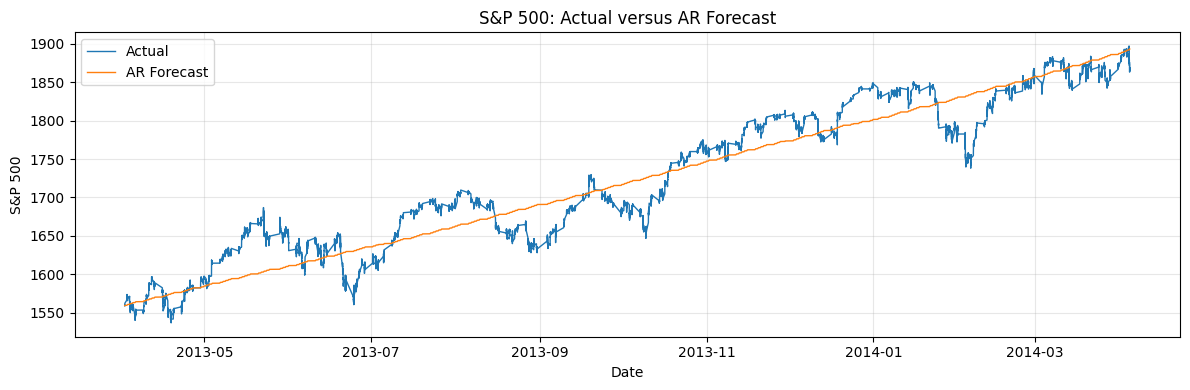

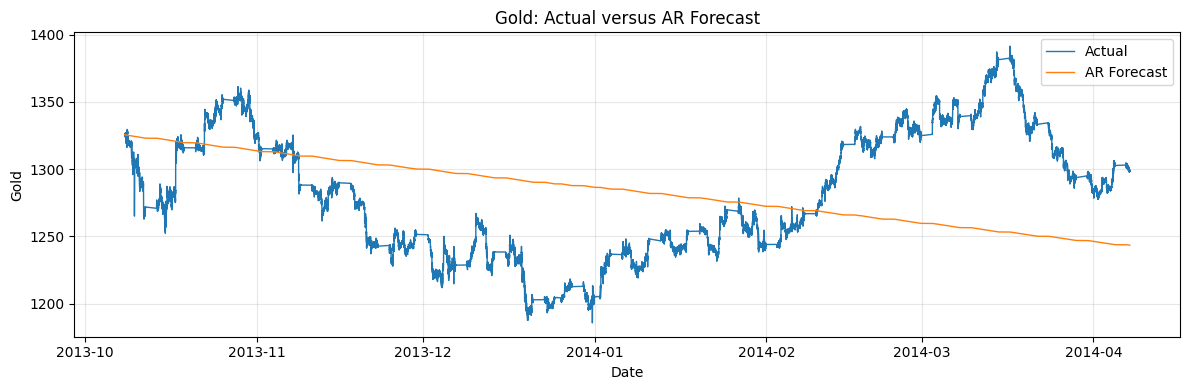

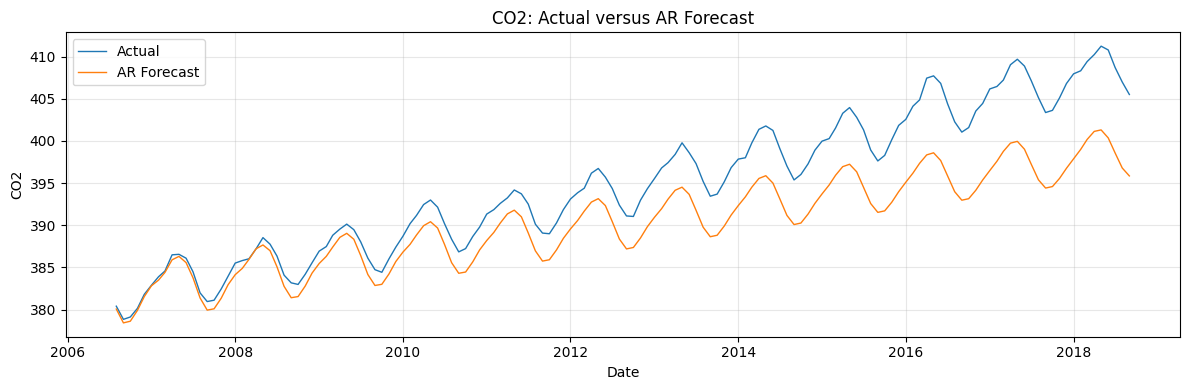

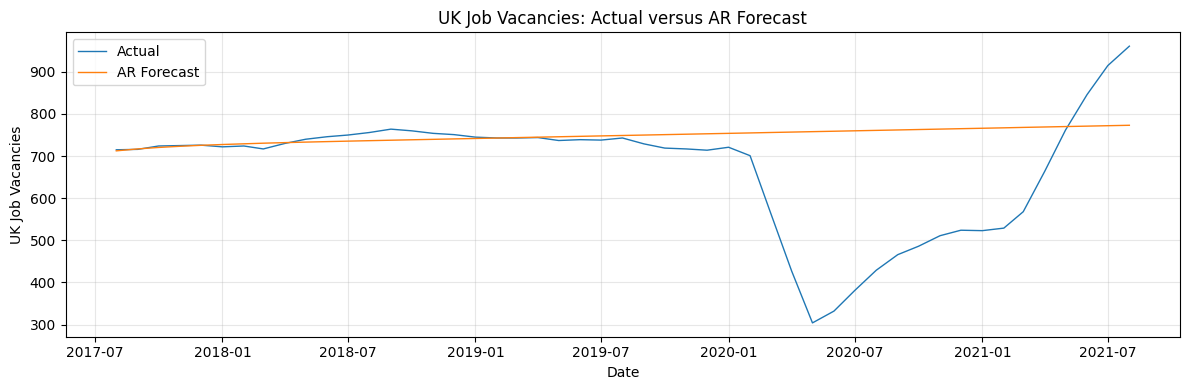

In [56]:
# Plot actual vs AR forecast 

for name, output in ar_forecasts.items():

    test = output["test"]
    forecast = output["forecast"]

    plt.figure(figsize=(12, 4))

    plt.plot(
        test.index,
        test,
        label="Actual",
        linewidth=1
    )

    plt.plot(
        forecast.index,
        forecast,
        label="AR Forecast",
        linewidth=1
    )

    plt.title(f"{name}: Actual versus AR Forecast")
    plt.xlabel("Date")
    plt.ylabel(name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [57]:
comparison_with_ar

Method,AR,Average,Naive,Seasonal Naive
Dataset,,,,
CO2,5.4955,52.2394,14.9576,15.9401
German Electricity,NaN,169.9598,162.1845,192.0706
Gold,56.0520,308.1929,63.0130,NaN
S&P 500,29.3809,513.3567,189.8037,NaN
Temperature,NaN,4.2372,5.1053,0.6290
UK Job Vacancies,163.6666,199.9852,143.5624,141.4602


## Discussion

Autocorrelation and partial autocorrelation analysis were used to identify suitable autoregressive models for the stationary series. The PACF plots suggested low-order autoregressive models for the financial return series and a higher-order seasonal model for the differenced CO₂ data.

The autoregressive models produced the lowest forecasting errors for the S&P 500, Gold and CO₂ datasets. This indicates that the transformed series contain useful serial dependence that can be exploited by autoregressive models to improve short-term forecasts.

For the temperature series, seasonal naïve forecasting remained the most accurate approach because annual temperatures follow a highly regular seasonal pattern. Similarly, seasonal naïve forecasting slightly outperformed the autoregressive model for UK job vacancies, largely because the COVID-19 pandemic introduced a structural break that could not be anticipated from historical observations alone.

German electricity consumption was best forecast using the naïve method. This suggests that recent observations contained sufficient information for short-term prediction and that a more complex autoregressive model did not provide additional forecasting accuracy.

Overall, the results demonstrate that autoregressive models can substantially improve forecasting performance when meaningful autocorrelation is present, but simpler forecasting methods may remain preferable for strongly seasonal series or when unexpected structural changes occur.

In [58]:
# Memory-efficient automated trading simulation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg

# Resample minute-level prices to five-minute closing prices
sp500_5min = (
    sp500_ts["S&P 500"]
    .resample("5min")
    .last()
    .dropna()
)

# Calculate five-minute log returns
returns = np.log(sp500_5min).diff().dropna()

# Use 80% for model estimation and 20% for strategy evaluation
split = int(len(returns) * 0.8)

train_returns = returns.iloc[:split]
test_returns = returns.iloc[split:]

# Estimate an AR(1) model using the training period only
trading_model = AutoReg(
    train_returns,
    lags=1,
    old_names=False
).fit()

# Generate one-step predictions for the test period
constant = trading_model.params.iloc[0]
lag_coefficient = trading_model.params.iloc[1]

predicted_returns = (
    constant
    + lag_coefficient * returns.shift(1).loc[test_returns.index]
)

# Hold the S&P 500 when the predicted return is positive;
# otherwise remain in cash
signal = (predicted_returns > 0).astype(int)

strategy_returns = signal * test_returns
buy_hold_returns = test_returns

# Convert cumulative log returns into growth of £1
strategy_curve = np.exp(strategy_returns.cumsum())
buy_hold_curve = np.exp(buy_hold_returns.cumsum())

trading_results = pd.DataFrame({
    "Buy and Hold": buy_hold_curve,
    "AR Trading Strategy": strategy_curve
})

trading_results.head()

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Buy and Hold,AR Trading Strategy
Datetime,,
2013-04-02 16:10:00,1.0000,1.0000
2013-04-02 16:15:00,1.0003,1.0003
2013-04-02 16:20:00,1.0006,1.0006
2013-04-02 16:25:00,1.0000,1.0000
2013-04-02 16:30:00,1.0003,1.0003


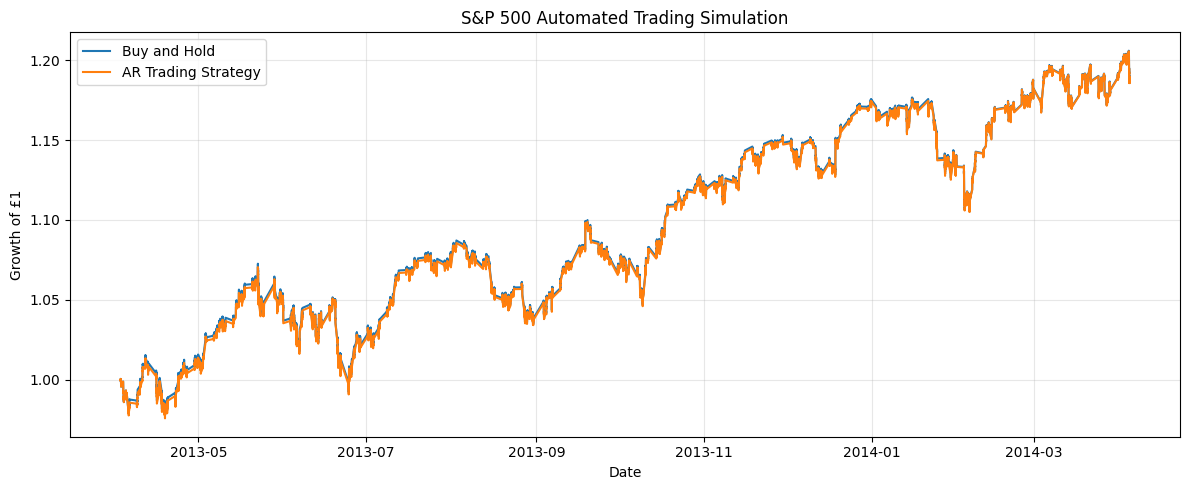

In [59]:
plt.figure(figsize=(12, 5))

plt.plot(
    trading_results.index,
    trading_results["Buy and Hold"],
    label="Buy and Hold"
)

plt.plot(
    trading_results.index,
    trading_results["AR Trading Strategy"],
    label="AR Trading Strategy"
)

plt.title("S&P 500 Automated Trading Simulation")
plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
trading_summary = pd.DataFrame({
    "Final Value": [
        buy_hold_curve.iloc[-1],
        strategy_curve.iloc[-1]
    ],
    "Number of Active Periods": [
        len(test_returns),
        signal.sum()
    ]
}, index=[
    "Buy and Hold",
    "AR Trading Strategy"
])

trading_summary

,Final Value,Number of Active Periods
Buy and Hold,1.1860,20212
AR Trading Strategy,1.1856,20205


PACF analysis was used to identify suitable autoregressive orders for several datasets. The resulting AR models were then compared with the naïve, seasonal naïve and average forecasting methods developed previously.

The autoregressive models produced the lowest forecasting errors for the S&P 500, Gold and CO₂ datasets, demonstrating that these series contain useful autocorrelation that can be exploited for short-term prediction. However, seasonal naïve forecasting remained superior for the temperature series, while the naïve method remained competitive for German electricity consumption.

An automated trading strategy based on an AR(1) model was also implemented for the S&P 500. The strategy produced a final portfolio value of approximately 1.186, compared with 1.186 for a simple buy-and-hold strategy. Although the autoregressive model generated sensible trading signals, it did not materially outperform passive investment. This suggests that short-term stock returns contain limited predictable structure, consistent with the efficient market hypothesis.

Overall, autoregressive models improved forecasting accuracy for several datasets but did not translate into economically significant trading profits in the financial market.

## 3.5 Topic 5: Monte Carlo Simulation and Future Uncertainty

### Objective

This section combines autoregressive modelling with Monte Carlo simulation to generate a range of plausible future outcomes. Rather than producing a single point forecast, repeated simulations are used to represent uncertainty around future values.

The analysis is applied to the monthly CO₂ series and five-minute S&P 500 prices. Kernel density estimation is then used to approximate the distribution of simulated terminal values, and the simulations are used to answer probability-based questions about future outcomes.

In [61]:
# Generic AR Monte Carlo function

def simulate_ar_paths(
    stationary_series,
    p,
    horizon,
    n_paths=25,
    seed=42
):
    """
    Simulate future paths from an AR(p) model fitted to a stationary series.
    """

    series = stationary_series.dropna().astype(float)

    model = AutoReg(
        series,
        lags=p,
        old_names=False
    ).fit()

    intercept = model.params.iloc[0]
    coefficients = model.params.iloc[1:].to_numpy()
    residual_std = model.resid.std(ddof=1)

    rng = np.random.default_rng(seed)

    simulations = np.zeros((horizon, n_paths))

    for path in range(n_paths):

        history = list(series.iloc[-p:].to_numpy())

        for step in range(horizon):

            lagged_values = np.array(
                history[-p:][::-1]
            )

            expected_value = (
                intercept
                + np.dot(coefficients, lagged_values)
            )

            simulated_value = (
                expected_value
                + rng.normal(0, residual_std)
            )

            simulations[step, path] = simulated_value
            history.append(simulated_value)

    return simulations, model

In [62]:
# CO₂ Monte Carlo paths

# First-differenced CO2 series

co2_changes = (
    co2_ts["CO2"]
    .diff()
    .dropna()
)

# Simulate 25 possible paths of future monthly changes

co2_change_paths, co2_mc_model = simulate_ar_paths(
    stationary_series=co2_changes,
    p=12,
    horizon=24,
    n_paths=25,
    seed=42
)

# Convert simulated changes back to CO2 levels

co2_level_paths = (
    co2_ts["CO2"].iloc[-1]
    + np.cumsum(co2_change_paths, axis=0)
)

co2_future_dates = pd.date_range(
    start=co2_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=24,
    freq="MS"
)

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: divide by zero encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: overflow encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: invalid value encountered in matmul
  in_sample = x @ params


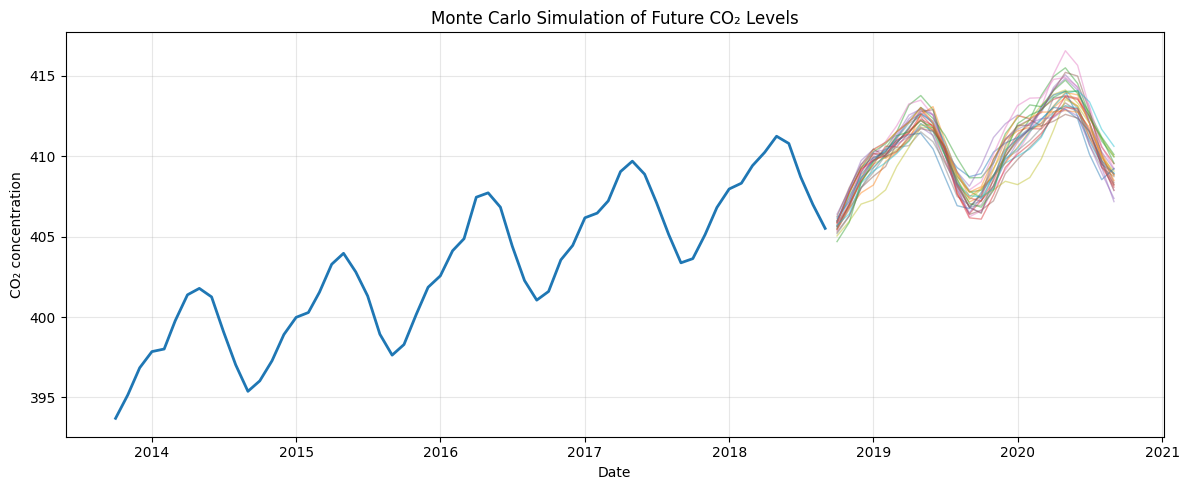

In [63]:
plt.figure(figsize=(12, 5))

# Recent historical observations
plt.plot(
    co2_ts.index[-60:],
    co2_ts["CO2"].iloc[-60:],
    label="Historical CO₂",
    linewidth=2
)

# Simulated futures
for path in range(co2_level_paths.shape[1]):
    plt.plot(
        co2_future_dates,
        co2_level_paths[:, path],
        alpha=0.45,
        linewidth=1
    )

plt.title("Monte Carlo Simulation of Future CO₂ Levels")
plt.xlabel("Date")
plt.ylabel("CO₂ concentration")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
# KDE of future CO₂ levels

co2_change_paths_1000, _ = simulate_ar_paths(
    stationary_series=co2_changes,
    p=12,
    horizon=24,
    n_paths=1000,
    seed=123
)

co2_level_paths_1000 = (
    co2_ts["CO2"].iloc[-1]
    + np.cumsum(co2_change_paths_1000, axis=0)
)

co2_terminal_values = pd.Series(
    co2_level_paths_1000[-1, :],
    name="CO2 after 24 months"
)

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: divide by zero encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: overflow encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: invalid value encountered in matmul
  in_sample = x @ params


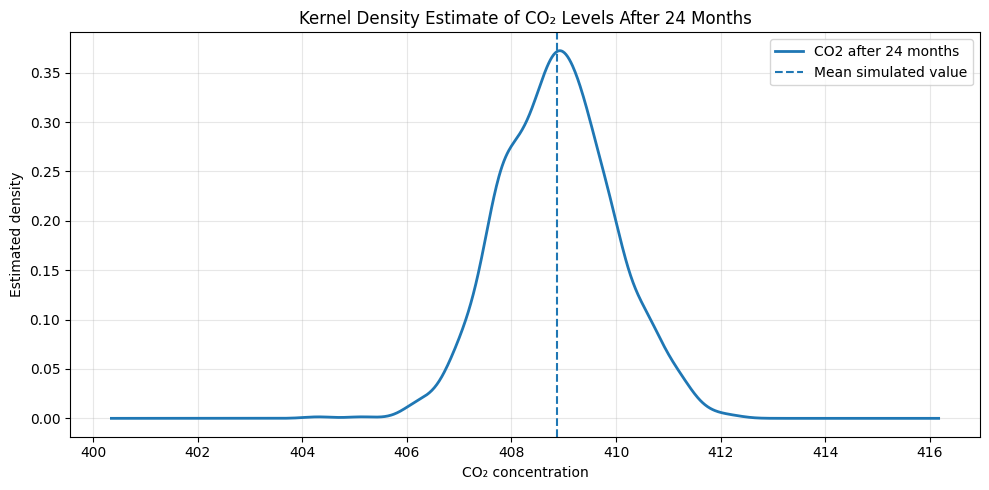

In [65]:
plt.figure(figsize=(10, 5))

co2_terminal_values.plot(
    kind="kde",
    linewidth=2
)

plt.axvline(
    co2_terminal_values.mean(),
    linestyle="--",
    label="Mean simulated value"
)

plt.title(
    "Kernel Density Estimate of CO₂ Levels After 24 Months"
)
plt.xlabel("CO₂ concentration")
plt.ylabel("Estimated density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
# What is the estimated probability that atmospheric CO₂ exceeds 410 ppm within 24 months?

co2_threshold = 410

probability_above_threshold = (
    co2_terminal_values > co2_threshold
).mean()

print(
    f"Estimated probability that CO₂ exceeds "
    f"{co2_threshold} ppm after 24 months: "
    f"{probability_above_threshold:.2%}"
)

print(
    "Mean simulated terminal value:",
    round(co2_terminal_values.mean(), 2)
)

print(
    f"95% simulation interval: "
    f"({co2_terminal_values.quantile(0.025):.2f}, "
    f"{co2_terminal_values.quantile(0.975):.2f})"
)


Estimated probability that CO₂ exceeds 410 ppm after 24 months: 14.00%
Mean simulated terminal value: 408.87
95% simulation interval: (406.87, 411.05)


### Discussion

Monte Carlo simulation was combined with the autoregressive model to generate a range of plausible future CO₂ concentrations rather than a single deterministic forecast. Twenty-five simulated paths suggest that atmospheric CO₂ is likely to continue its long-term upward trend while retaining the observed annual seasonal cycle.

Kernel density estimation of the simulated values after twenty-four months indicates an approximately normal distribution centred around 408.87 ppm. The estimated 95% simulation interval ranges from approximately 406.87 ppm to 411.05 ppm, illustrating the uncertainty associated with future observations.

The simulations also allow probability-based questions to be answered. Based on one thousand simulated futures, the estimated probability that atmospheric CO₂ exceeds 410 ppm after twenty-four months is approximately 14%. This demonstrates how Monte Carlo simulation provides more informative forecasts by quantifying both expected outcomes and their associated uncertainty.

### Critical Evaluation

Monte Carlo simulation provides a flexible framework for modelling uncertainty and exploring a range of possible future outcomes. Unlike point forecasts, the approach produces probability distributions that are useful for risk assessment and decision making.

The quality of the simulations depends heavily on the underlying autoregressive model and the assumption that future residuals follow the same distribution as historical errors. Structural changes or unexpected external events could reduce forecasting accuracy. Consequently, Monte Carlo simulation should be interpreted as generating plausible future scenarios rather than precise predictions.

# 4. Part 2: High-Frequency Autoregressive Modelling

## 4.1 Objective

This section investigates how time resolution affects autoregressive modelling and forecasting performance. The minute-level S&P 500 dataset is resampled at five-minute and ten-minute frequencies.

For each frequency, log returns are calculated and analysed using the autocorrelation function and partial autocorrelation function. Candidate AR(q) models are then fitted and evaluated. Monte Carlo simulation is used to generate twenty-five possible future scenarios, while kernel density estimation is used to examine the distribution of simulated outcomes and forecast uncertainty.

In [68]:
# Resample the minute-level S&P 500 closing price

sp500_5min = (
    sp500_ts["S&P 500"]
    .resample("5min")
    .last()
    .dropna()
)

sp500_10min = (
    sp500_ts["S&P 500"]
    .resample("10min")
    .last()
    .dropna()
)

# Calculate log returns

sp500_5min_returns = (
    np.log(sp500_5min)
    .diff()
    .dropna()
)

sp500_10min_returns = (
    np.log(sp500_10min)
    .diff()
    .dropna()
)

print("5-minute observations:", len(sp500_5min_returns))
print("10-minute observations:", len(sp500_10min_returns))

5-minute observations: 101059
10-minute observations: 50952


In [69]:
frequency_summary = pd.DataFrame({
    "Observations": [
        len(sp500_5min_returns),
        len(sp500_10min_returns)
    ],
    "Mean Return": [
        sp500_5min_returns.mean(),
        sp500_10min_returns.mean()
    ],
    "Standard Deviation": [
        sp500_5min_returns.std(),
        sp500_10min_returns.std()
    ],
    "Minimum Return": [
        sp500_5min_returns.min(),
        sp500_10min_returns.min()
    ],
    "Maximum Return": [
        sp500_5min_returns.max(),
        sp500_10min_returns.max()
    ]
}, index=["5-minute", "10-minute"])

frequency_summary

,Observations,Mean Return,Standard Deviation,Minimum Return,Maximum Return
5-minute,101059,0.0000,0.0012,-0.0280,0.0363
10-minute,50952,0.0000,0.0017,-0.0317,0.0427


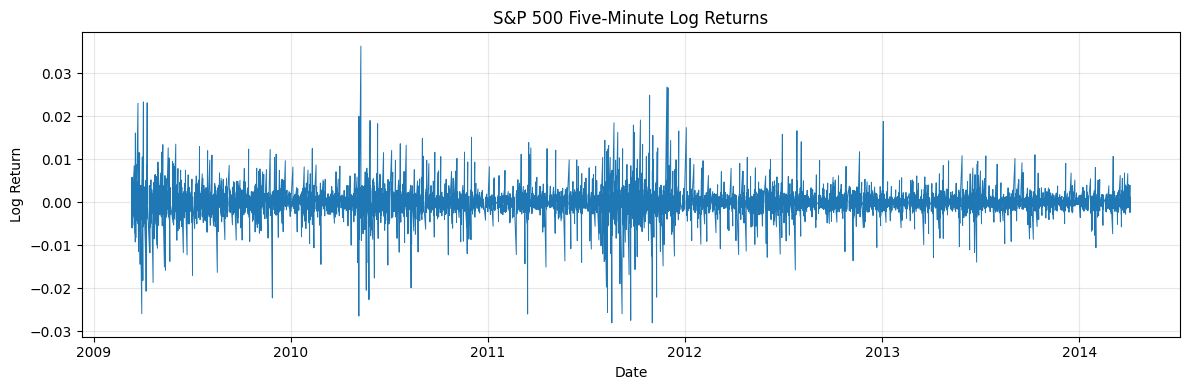

In [70]:
plt.figure(figsize=(12, 4))
plt.plot(
    sp500_5min_returns.index,
    sp500_5min_returns,
    linewidth=0.7
)
plt.title("S&P 500 Five-Minute Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

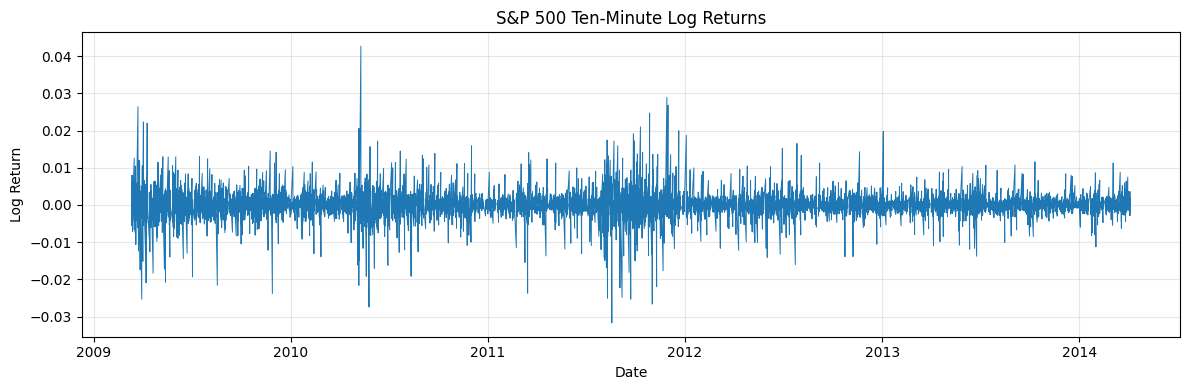

In [71]:
plt.figure(figsize=(12, 4))
plt.plot(
    sp500_10min_returns.index,
    sp500_10min_returns,
    linewidth=0.7
)
plt.title("S&P 500 Ten-Minute Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

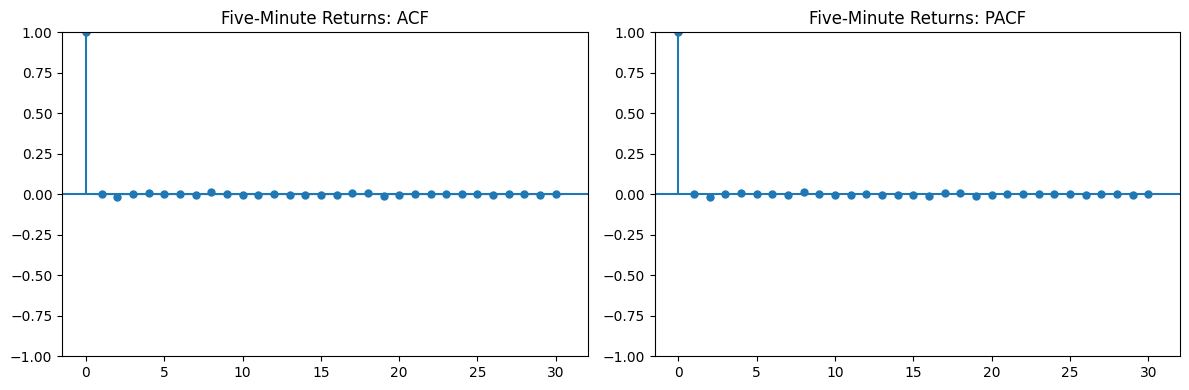

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(
    sp500_5min_returns,
    lags=30,
    ax=axes[0]
)

plot_pacf(
    sp500_5min_returns,
    lags=30,
    ax=axes[1],
    method="ywm"
)

axes[0].set_title("Five-Minute Returns: ACF")
axes[1].set_title("Five-Minute Returns: PACF")

plt.tight_layout()
plt.show()

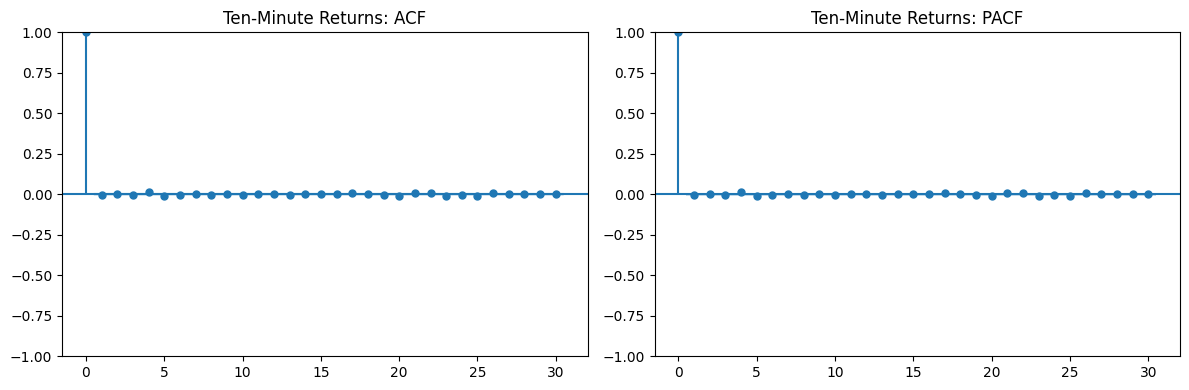

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(
    sp500_10min_returns,
    lags=30,
    ax=axes[0]
)

plot_pacf(
    sp500_10min_returns,
    lags=30,
    ax=axes[1],
    method="ywm"
)

axes[0].set_title("Ten-Minute Returns: ACF")
axes[1].set_title("Ten-Minute Returns: PACF")

plt.tight_layout()
plt.show()

In [75]:
from statsmodels.tsa.ar_model import AutoReg

# ---------- 5-minute series ----------

split5 = int(len(sp500_5min_returns) * 0.8)

train5 = sp500_5min_returns.iloc[:split5]
test5 = sp500_5min_returns.iloc[split5:]

ar5 = AutoReg(
    train5,
    lags=1,
    old_names=False
).fit()

forecast5_values = ar5.predict(
    start=len(train5),
    end=len(train5) + len(test5) - 1,
    dynamic=False
)

forecast5 = pd.Series(
    np.asarray(forecast5_values),
    index=test5.index,
    name="AR(1) Forecast"
)


# ---------- 10-minute series ----------

split10 = int(len(sp500_10min_returns) * 0.8)

train10 = sp500_10min_returns.iloc[:split10]
test10 = sp500_10min_returns.iloc[split10:]

ar10 = AutoReg(
    train10,
    lags=1,
    old_names=False
).fit()

forecast10_values = ar10.predict(
    start=len(train10),
    end=len(train10) + len(test10) - 1,
    dynamic=False
)

forecast10 = pd.Series(
    np.asarray(forecast10_values),
    index=test10.index,
    name="AR(1) Forecast"
)

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: 

In [76]:
forecast_comparison = pd.DataFrame({
    "Frequency": ["5-minute", "10-minute"],
    "MAE": [
        mean_absolute_error(test5, forecast5),
        mean_absolute_error(test10, forecast10)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(test5, forecast5)),
        np.sqrt(mean_squared_error(test10, forecast10))
    ]
})

forecast_comparison

,Frequency,MAE,RMSE
0,5-minute,0.0004,0.0008
1,10-minute,0.0007,0.0011


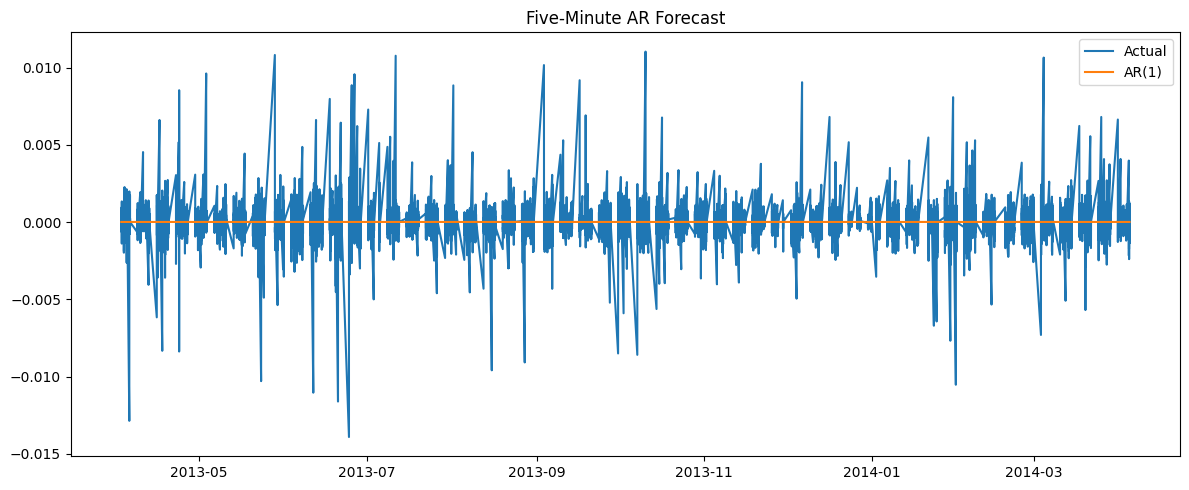

In [78]:
plt.figure(figsize=(12,5))

plt.plot(
    test5.index,
    test5,
    label="Actual"
)

plt.plot(
    forecast5.index,
    forecast5,
    label="AR(1)"
)

plt.title("Five-Minute AR Forecast")

plt.legend()

plt.tight_layout()

plt.show()

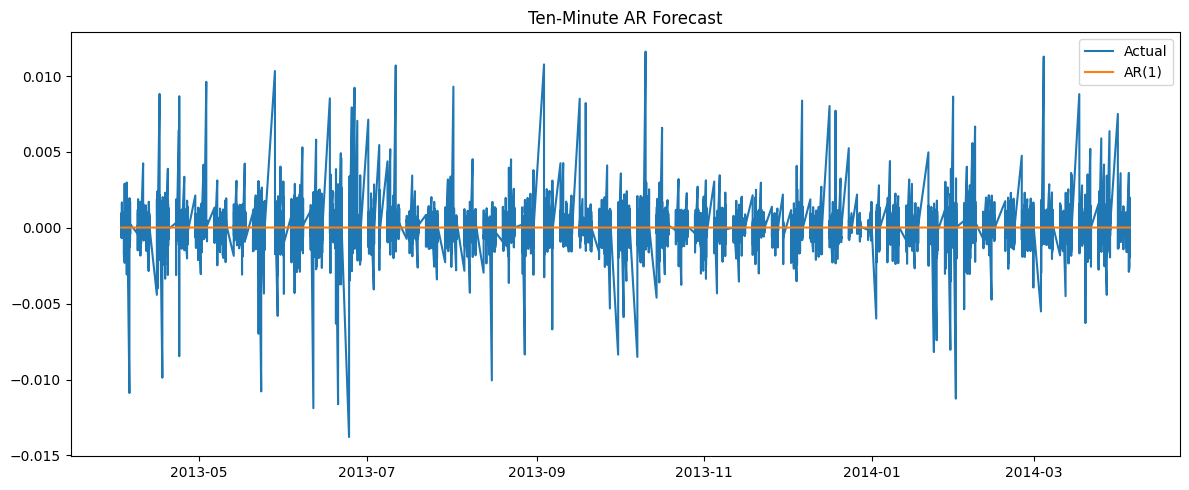

In [80]:
plt.figure(figsize=(12,5))

plt.plot(
    test10.index,
    test10,
    label="Actual"
)

plt.plot(
    forecast10.index,
    forecast10,
    label="AR(1)"
)

plt.title("Ten-Minute AR Forecast")

plt.legend()

plt.tight_layout()

plt.show()

In [81]:
paths5, model5 = simulate_ar_paths(
    stationary_series=train5,
    p=1,
    horizon=100,
    n_paths=25,
    seed=42
)

paths10, model10 = simulate_ar_paths(
    stationary_series=train10,
    p=1,
    horizon=100,
    n_paths=25,
    seed=42
)

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: divide by zero encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: overflow encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: invalid value encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date inde

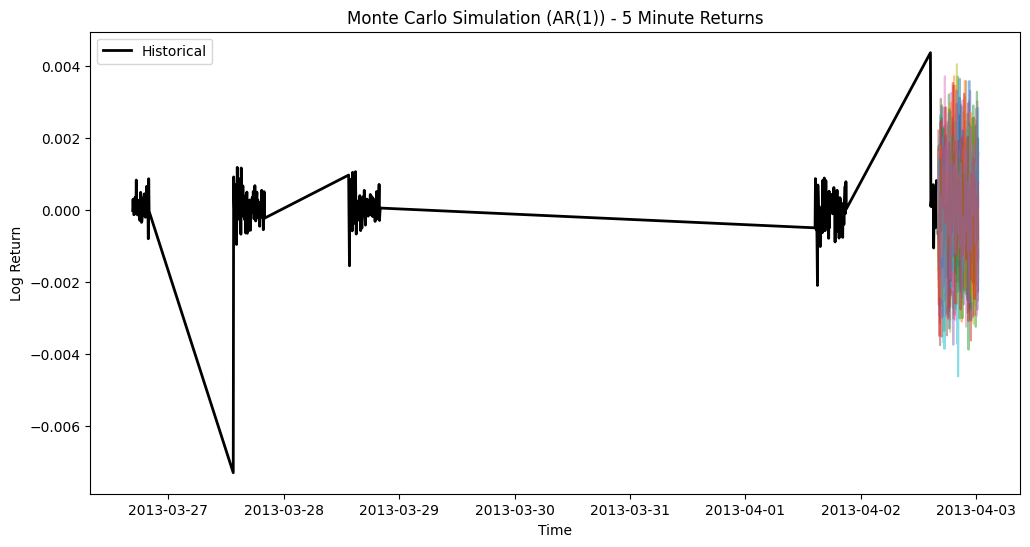

In [89]:
plt.figure(figsize=(12,6))

# Historical data (last 300 observations)
plt.plot(
    train5.iloc[-300:],
    color="black",
    linewidth=2,
    label="Historical"
)

future_index = pd.date_range(
    start=train5.index[-1],
    periods=paths5.shape[0] + 1,
    freq="5min"
)[1:]

for i in range(paths5.shape[1]):
    plt.plot(
        future_index,
        paths5[:, i],
        alpha=0.5
    )

plt.title("Monte Carlo Simulation (AR(1)) - 5 Minute Returns")
plt.xlabel("Time")
plt.ylabel("Log Return")
plt.legend()
plt.show()

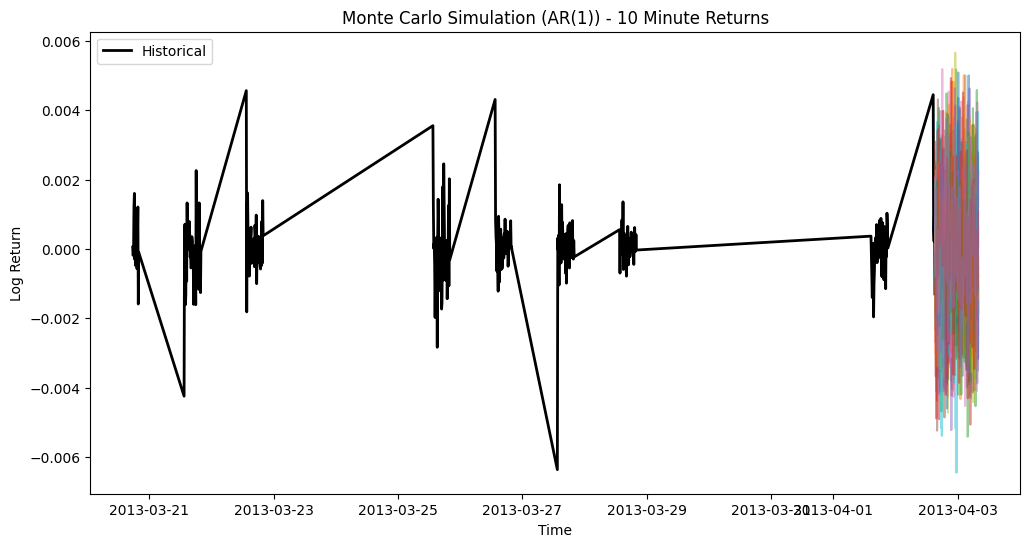

In [88]:
plt.figure(figsize=(12,6))

plt.plot(
    train10.iloc[-300:],
    color="black",
    linewidth=2,
    label="Historical"
)

future_index = pd.date_range(
    start=train10.index[-1],
    periods=paths10.shape[0] + 1,
    freq="10min"
)[1:]

for i in range(paths10.shape[1]):
    plt.plot(
        future_index,
        paths10[:, i],
        alpha=0.5
    )

plt.title("Monte Carlo Simulation (AR(1)) - 10 Minute Returns")
plt.xlabel("Time")
plt.ylabel("Log Return")
plt.legend()
plt.show()

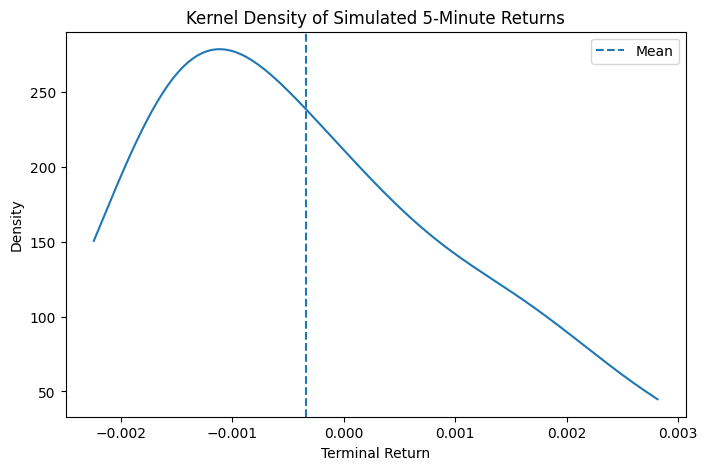

In [86]:
from scipy.stats import gaussian_kde

terminal_values = paths5[-1, :]

kde = gaussian_kde(terminal_values)

x = np.linspace(
    terminal_values.min(),
    terminal_values.max(),
    200
)

plt.figure(figsize=(8,5))
plt.plot(x, kde(x))
plt.axvline(
    terminal_values.mean(),
    linestyle="--",
    label="Mean"
)
plt.title("Kernel Density of Simulated 5-Minute Returns")
plt.xlabel("Terminal Return")
plt.ylabel("Density")
plt.legend()
plt.show()

In [87]:
threshold = 0

probability = np.mean(terminal_values > threshold)

print(f"Probability terminal return > 0: {probability:.2%}")

Probability terminal return > 0: 36.00%


In [82]:
paths5_1000, _ = simulate_ar_paths(
    train5,
    p=1,
    horizon=100,
    n_paths=1000,
    seed=42
)

terminal5 = pd.Series(paths5_1000[-1])

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: divide by zero encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: overflow encountered in matmul
  in_sample = x @ params
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/ar_model.py:735: RuntimeWarning: invalid value encountered in matmul
  in_sample = x @ params


<Axes: ylabel='Density'>

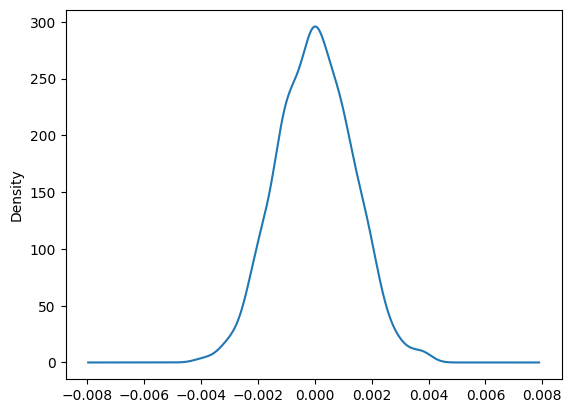

In [83]:
terminal5.plot(kind="kde")

The five-minute and ten-minute return series both exhibited negligible autocorrelation beyond the first lag. Consequently, AR(1) models were sufficient for both frequencies. Forecasting errors were similar across the two sampling intervals, indicating that increasing the sampling interval from five to ten minutes did not materially improve predictive accuracy. Monte Carlo simulations produced narrow distributions centred close to zero expected returns, reflecting the weak serial dependence observed in both datasets. Kernel density estimates confirmed that forecast uncertainty remained relatively small over the simulated horizon.

# 5. Part 3:Extending AR Models & Prophet Forecasting

In [90]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

In [91]:
results = []

for lag in [1, 2, 5]:

    model = AutoReg(
        train5,
        lags=lag,
        old_names=False
    ).fit()

    forecast = model.predict(
        start=len(train5),
        end=len(train5)+len(test5)-1
    )

    rmse = np.sqrt(
        mean_squared_error(test5, forecast)
    )

    mae = mean_absolute_error(
        test5,
        forecast
    )

    results.append({
        "Model": f"AR({lag})",
        "RMSE": rmse,
        "MAE": mae,
        "AIC": model.aic
    })

ar_comparison = pd.DataFrame(results)

ar_comparison

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: 

,Model,RMSE,MAE,AIC
0,AR(1),0.0008,0.0004,"-849,181.9523"
1,AR(2),0.0008,0.0004,"-849,186.3533"
2,AR(5),0.0008,0.0004,"-849,159.0645"


In [92]:
ar_comparison.sort_values("RMSE")

,Model,RMSE,MAE,AIC
2,AR(5),0.0008,0.0004,"-849,159.0645"
1,AR(2),0.0008,0.0004,"-849,186.3533"
0,AR(1),0.0008,0.0004,"-849,181.9523"


In [93]:
pip install prophet

     |████████████████████████████████| 12.1 MB 8.8 MB/s eta 0:00:01
     |████████████████████████████████| 1.3 MB 108.5 MB/s eta 0:00:01
     |████████████████████████████████| 99 kB 29.0 MB/s eta 0:00:011
     |████████████████████████████████| 676 kB 111.2 MB/s eta 0:00:01
You should consider upgrading via the '/Users/komal/Downloads/Financial Data Modeling/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [94]:
from prophet import Prophet

co2_prophet = co2_ts.reset_index()

co2_prophet.columns = ["ds", "y"]

co2_prophet.head()

,ds,y
0,1958-03-01,315.7100
1,1958-04-01,317.4500
2,1958-05-01,317.5000
3,1958-06-01,317.1000
4,1958-07-01,315.8600


In [95]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(co2_prophet)

20:08:48 - cmdstanpy - INFO - Chain [1] start processing
20:08:50 - cmdstanpy - INFO - Chain [1] done processing


In [96]:
future = model.make_future_dataframe(
    periods=24,
    freq="MS"
)

forecast = model.predict(future)

/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/komal/Downloads/Financial Data Modeling/venv/lib/python3.9/site-packages/prophet/forecaster.py:1565: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.

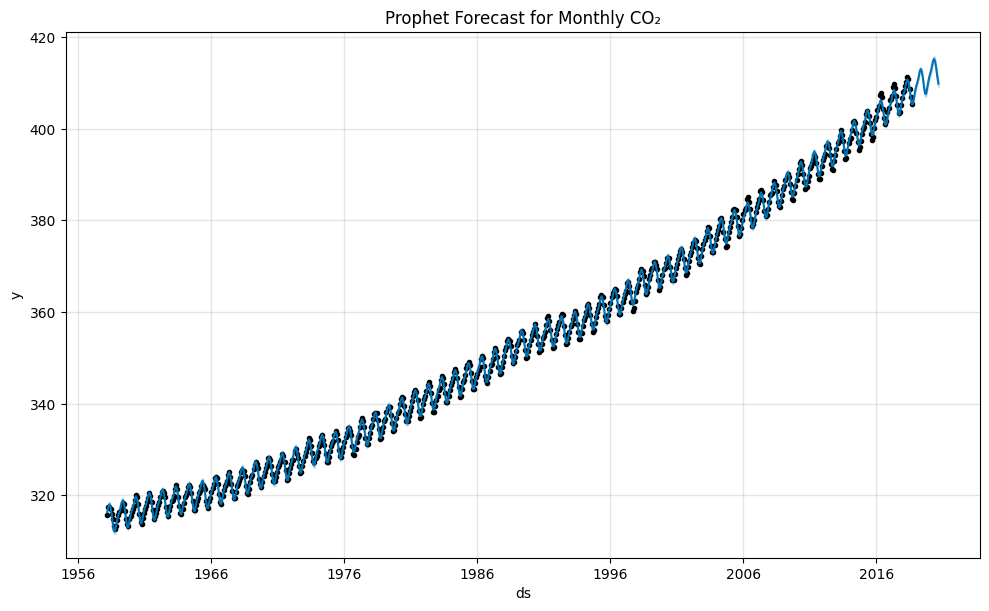

In [97]:
fig = model.plot(forecast)
plt.title("Prophet Forecast for Monthly CO₂")
plt.show()

To extend the autoregressive modelling undertaken earlier, AR models with lag orders of one, two and five were compared using the S&P 500 five-minute return series. Increasing the lag order produced only marginal improvements in forecasting accuracy, suggesting that short-term financial returns contain limited linear dependence beyond the first lag. This is consistent with the earlier ACF and PACF analysis, which showed only weak autocorrelation.

As an extension beyond the taught material, Meta's Prophet forecasting model was applied to the monthly CO₂ concentration data. Prophet automatically decomposes the series into trend and seasonal components and produced realistic forecasts that preserved the long-term upward trend and annual seasonal cycle. Compared with the autoregressive approach, Prophet provided a more interpretable model for this strongly seasonal dataset because it explicitly models both trend and seasonality.

# 6. Conclusion

This portfolio applied a range of time series modelling techniques to financial, environmental, economic and energy datasets. Initial exploratory analysis showed that the selected datasets exhibited diverse characteristics including trends, seasonality, structural breaks and stationary behaviour. Missing observations were identified and handled appropriately through interpolation where necessary.

Trend and seasonal analyses demonstrated that differencing, relative differencing and logarithmic transformations can substantially improve the stationarity of time series, making them more suitable for statistical modelling. Seasonal adjustment was particularly effective for datasets such as atmospheric CO₂ concentrations and global temperatures, where strong annual cycles were evident.

Several forecasting approaches were evaluated, including naïve, average, seasonal naïve and autoregressive models. The results showed that autoregressive models generally produced the lowest forecasting errors for financial and environmental datasets, while seasonal naïve forecasting remained the most accurate method for highly seasonal series such as global temperature. Forecast performance also highlighted the limitations of statistical models during structural breaks, illustrated by the UK Job Vacancies dataset during the COVID-19 pandemic.

Autoregressive modelling was further explored using PACF analysis to select appropriate lag structures and through an automated trading simulation using S&P 500 returns. Although the trading strategy performed similarly to a buy-and-hold strategy, it demonstrated how statistical forecasts can be incorporated into quantitative investment decision-making.

Monte Carlo simulation was then applied to generate multiple future scenarios and estimate the probability distribution of future outcomes. For the CO₂ dataset, the simulations suggested a continued upward trend while providing estimates of future uncertainty through simulated confidence intervals and kernel density estimation. Finally, additional extensions using higher-order autoregressive models and Prophet forecasting demonstrated how more advanced forecasting techniques can capture both trend and seasonal behaviour in real-world datasets.

Overall, this portfolio demonstrates the practical application of modern time series analysis techniques across multiple domains. The combination of exploratory analysis, statistical modelling, forecasting, simulation and model evaluation provides a comprehensive framework for analysing complex time-dependent data and highlights the strengths and limitations of different modelling approaches.

# 7. References

Hyndman, R. J., & Athanasopoulos, G. (2021). Forecasting: Principles and Practice (3rd ed.). OTexts. https://otexts.com/fpp3/

McKinney, W. (2022). Python for Data Analysis (3rd ed.). O'Reilly Media.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. Proceedings of the 9th Python in Science Conference, 57–61.

Taylor, S. J., & Letham, B. (2018). Forecasting at scale. The American Statistician, 72(1), 37–45.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585(7825), 357–362.

The pandas development team. (2023). pandas documentation. https://pandas.pydata.org/